# Detección de Objetos

En este notebook se entrenará el modelo. Se realizarán varias iteraciones pues el dataset irá aumentando mediante active learning.

Además inicialmente se han etiquetado manualmente 100 imagenes de otros partidos de futbol oficiales de todo tipo de ligas distintas que se usarán como conjunto de Test para ver como se comporta el modelo. En consecuencia, habrá dos conjuntos de Test: el de Soccernet y el nuestro propio.


Debido al pequeño tamaño del dataset se ha decidido emplear fine tuning para entrenar el modelo.


In [2]:
import importlib
from ultralytics import YOLO
import supervision as sv
import numpy as np
import cv2
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from ia_futbol.utils.image_tools import display_image

%load_ext autoreload
%autoreload 2

"""
Funciones Auxiliares para facilitar la lectura del notebook
"""

def recall(cm):
    
    TP = np.diag(cm)
    FN = np.sum(cm, axis=1) - TP

    recall = TP / (TP + FN)
    recall_overall = np.mean(recall)

    return recall_overall

def precision(cm):
        
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    
    precision = TP / (TP + FP)
    precision_overall = np.mean(precision)
  
    return precision_overall

def metrics(results):
    #results: array de resultados
    mAP50_95s = [result.box.map for result in results]
    mAP50s = [result.box.map50 for result in results]
    mAP75s = [result.box.map75 for result in results]
    precisions = [precision(result.confusion_matrix.to_df().to_numpy()[:,1:]) for result in results]
    recalls  = [recall(result.confusion_matrix.to_df().to_numpy()[:,1:]) for result in results]

   
    df = pd.DataFrame(
        data=[mAP50_95s, mAP50s, mAP75s, precisions, recalls],
        index=["mAP50-95", "mAP50", "mAP75", "Precision", "Recall"]
    )
    
    # Opcional: renombrar columnas si quieres que indiquen cada resultado
    df.columns = [f"Iteracion{i}" for i in range(len(results))]
    
    return df


# Iteración 0

* Número imagenes train: $2580$
* Número imágenes val: $300$
* Número imágenes test soccernet : $ 300 $
* Número imágenes test: $ 100 $


Aplicaremos fine tuning a un modelo con pesos iniciales entrenado con el famoso dataset COCO

In [ ]:
#Entrenamiento del modelo 
DATA_PATH = "../dataset/object_detection/data.yaml" #Ruta al dataset
OUTPUT_PATH = "models" #Ruta donde se almacena el modelo entrenado

model = YOLO("yolov8m.pt")  #Modelo con pesos
model.train(
    data=DATA_PATH,
    epochs=100,
    imgsz=640,
    batch=8,
    device=0
)

Mostramos la progresión del entrenamiento

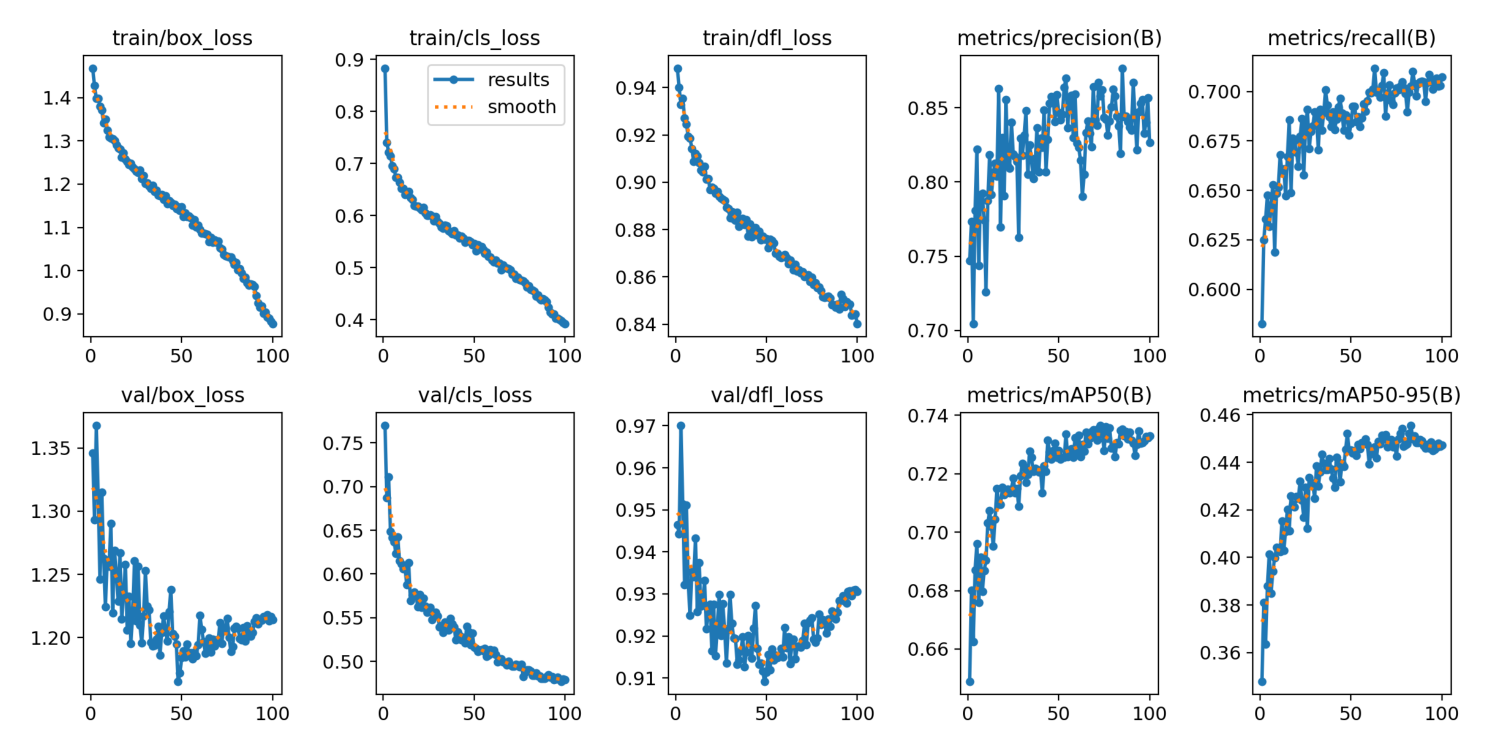

In [3]:
from ia_futbol.utils.config import OBJ_DETECTION_RUN0
display_image(os.path.join(OBJ_DETECTION_RUN0,"results_train.png"))

Esta imagen muestra la progresión y los resultados obtenidos durante el entrenamiento. Explicaremos las funciones de pérdida:

- Box Loss: indica que tan bien las cajas (bounding boxes) predichas por el modelo se alinean con las cajas reales.
- Class Loss: indica que tan bien el modelo predice la clase correcta del objeto detectado
- DFL (Distribution Focal Loss): indica que tan bien el modelo predice las esquinas de las cajas.El modelo, en vez de predecir un solo punto
para la esquina, predice varios y les asigna distintas probabilidades.

Además se tienen las siguientes métricas:



- Precisión: Porcentaje de predicciones correctas

    $ \text{Precision} = \frac{TP}{TP + FP} $




- Recall: Porcentaje de objetos reales detectados:


    $\text{Recall} = \frac{TP}{TP + FN}$



- mAP50 (mean Average Precision @ IoU=0.5): Mide la precisión global considerando el solapamiento de cajas

    $ \text{mAP50} = \frac{1}{C} \sum_{i=1}^{C} AP_i $


    - IoU ≥ 0.5 para considerar una predicción correcta  
    - $AP_i $ = área bajo la curva Precision vs Recall para cada clase

- mAP50-95 (mean Average Precision @ IoU=0.5:0.95) :Mide la precisión global del modelo considerando diferentes niveles de solapamiento (IoU):






Observando un poco las gráficas se aprecia que a partir del epoch 50 se produce sobreaprendizaje, sin embargo, las métricas tienden a mejorar a partir de dicho epoch.  

YOLO ofrece siempre los pesos del último epoch y del mejor epoch, es decir, de aquel cuyo mAP50-95 sea mejor.

In [ ]:
#Cargamos los pesos del mejor modelo
model_0 = YOLO(os.path.join(OBJ_DETECTION_RUN0,"weights","best.pt")).to("cpu")

## Test Soccernet

Aplicaremos el modelo entrenado sobre el conjunto de test obtenido de Soccernet para ver su comportamiento.
YOLO no ofrece un método directo para aplicar el modelo sobre un conjunto de datos específico, es necesario definir un archivo .yaml donde se indique
que conjunto es el de validacion, en este caso, el de test.


In [ ]:
from ia_futbol.utils.config import OBJ_DETECTION_DATA

#TEST SOCCERNET
results_test_soccernet = model_0.val(
    data=os.path.join(OBJ_DETECTION_DATA, "soccernet_test.yaml"),
    project=os.path.join(OBJ_DETECTION_RUN0,"soccernet_test"),
    name='test_soccernet',
    verbose = False
)


Ultralytics 8.3.239 🚀 Python-3.12.2 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6064MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7078.2±1356.7 MB/s, size: 239.9 KB)
val: Scanning /home/adrian/IA-Futbol/object_detection/dataset/test/labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 1.1Mit/s 0.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.4it/s 5.6s0.3s
                   all        300       4434       0.79      0.676      0.699      0.441
Speed: 0.5ms preprocess, 16.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/adrian/IA-Futbol/object_detection/results/it_0/test_soccernet2


In [61]:
metrics([results_test_soccernet])

,Iteracion0
mAP50-95,0.440696
mAP50,0.699358
mAP75,0.491759
Precision,0.500719
Recall,0.627873


Observamos que mAP50 es relativamente alto, lo que indica que el modelo detecta bien los objetos cuando el criterio de IoU es más flexible.


Sin embargo, cuando se exige mas precisión en la posicion de los bounding boxes el desempeño es peor, pues los valores de MAP50-95 y mAP75 no son tan altos.


La precision, teniendo en cuenta el recall, sugiere que hay una cantidad considerable de falsos positivos.


Por ultimo, el recall es aceptable, indicando que el modelo logra encontrar buena parte de los objetos.

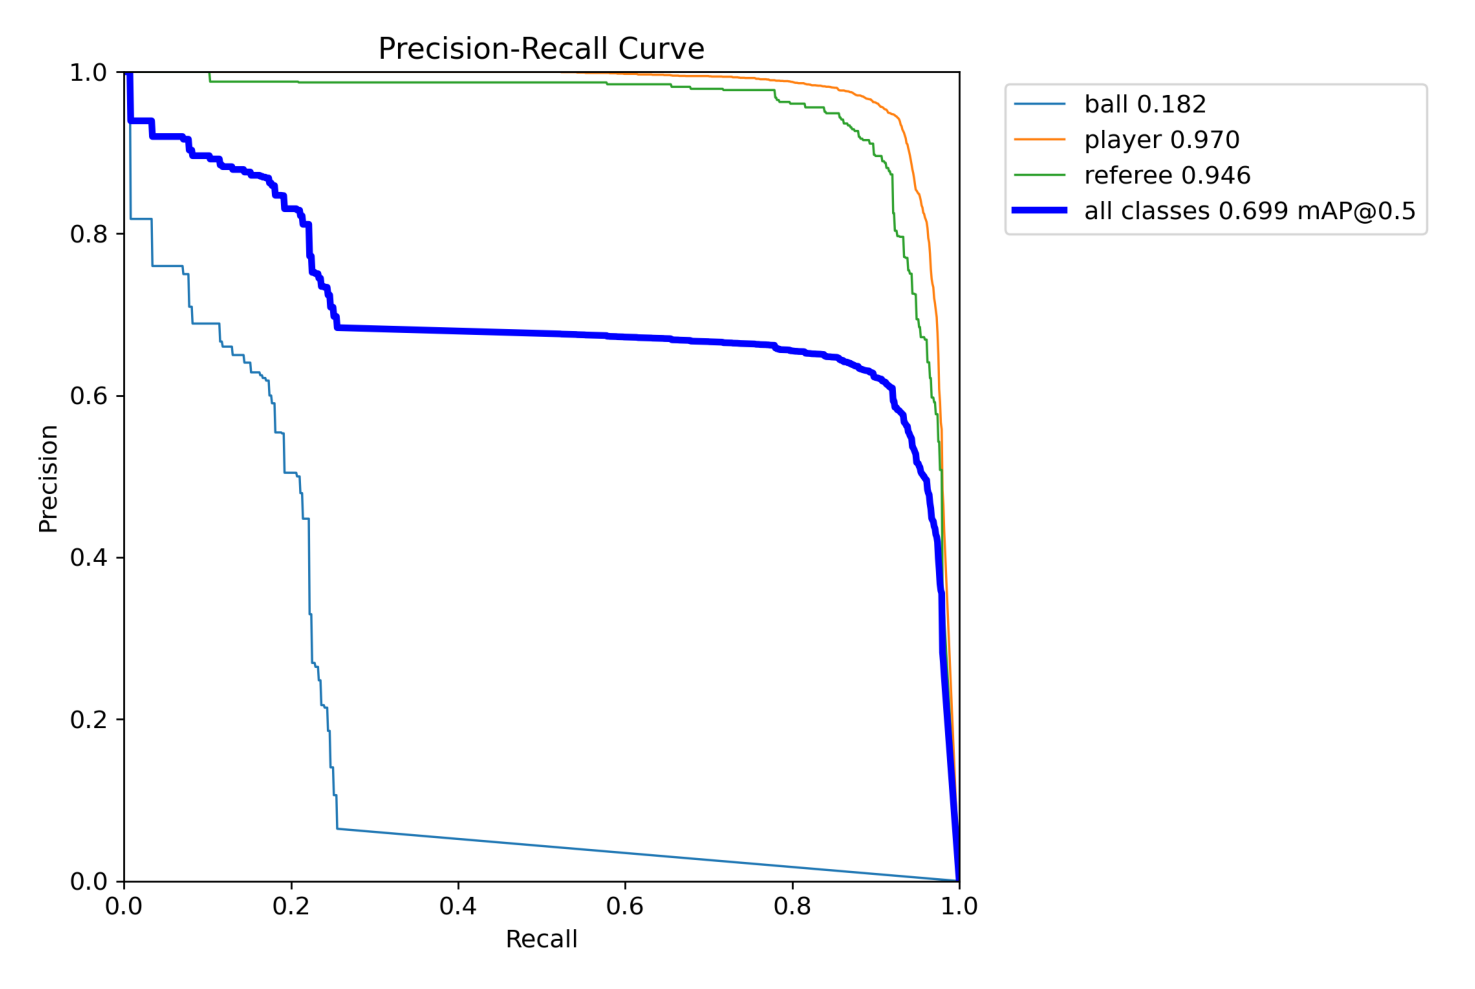

In [4]:
display_image(os.path.join(OBJ_DETECTION_RUN0, "soccernet_test", "BoxPR_curve.png"))


Aqui se aprecia que la relación precision-recall es muy buena en las clases de jugador y arbitro. Cuando se aumenta el recall la precisión no se ve perjudicada.
Sin embargo, en el caso de la pelota, si queremos que el recall aumente, la precision disminuye, es decir, el modelo detecta mas objetos reales pero tambien aumenta el numero de falsos positivos.

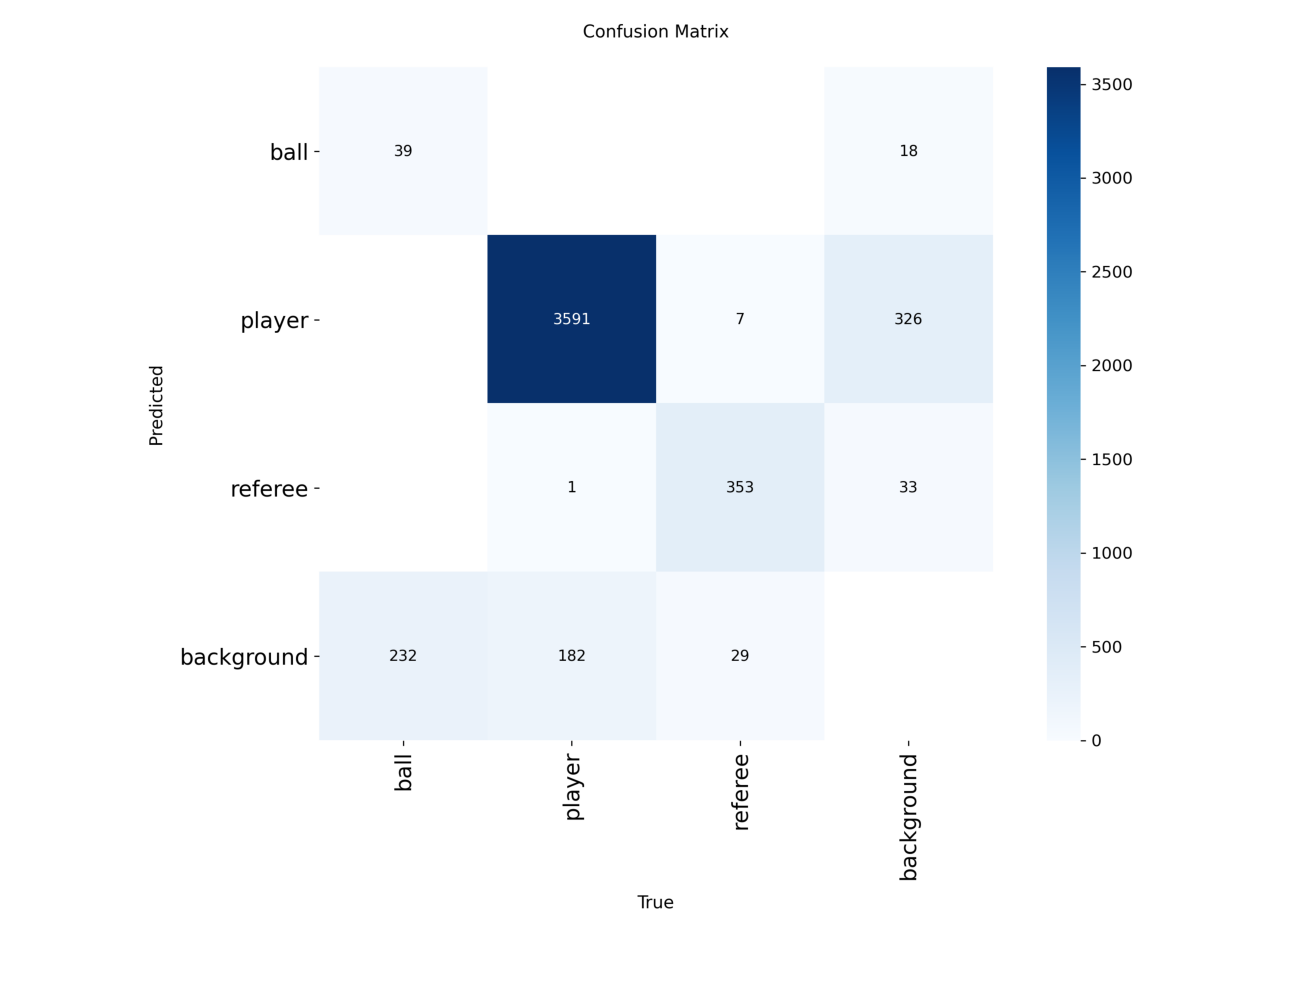

In [5]:
display_image(os.path.join(OBJ_DETECTION_RUN0, "soccernet_test", "confusion_matrix.png"))


El modelo es malo detectando el balón y, en general, bueno con arbitros y jugadores

## Test Propio

In [ ]:
#NEW TEST
results_new_test = model_0.val(
    data=os.path.join(OBJ_DETECTION_DATA, "custom_test.yaml"),
    project=os.path.join(OBJ_DETECTION_RUN0,"custom_test"),
    name='test_soccernet')

Ultralytics 8.3.239 🚀 Python-3.12.2 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6064MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5816.5±2161.5 MB/s, size: 276.7 KB)
val: Scanning /home/adrian/IA-Futbol/object_detection/dataset/new_test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 244.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.3it/s 2.1s0.3s
                   all        100       1674      0.526      0.551      0.475      0.288
                  ball         83         83      0.385      0.151      0.151      0.059
                player        100       1457      0.792      0.957      0.927      0.611
               referee         86        134      0.401      0.545      0.347      0.194
Speed: 1.1ms preprocess, 16.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /home/adrian/IA-Futbol/object_detection/results/it_0/new_test2

In [64]:
metrics([results_new_test])

,Iteracion0
mAP50-95,0.287972
mAP50,0.475340
mAP75,0.322608
Precision,0.369703
Recall,0.459036


Los resultados en nuestro conjunto de test son significativamente peores que los obtenidos en el test de SoccerNet. 

Esta diferencia es coherente y esperable, ya que el conjunto de test de SoccerNet contiene imágenes capturadas en condiciones muy similares a las del entrenamiento (misma liga, cámaras, iluminación y entorno). 

En cambio, nuestro conjunto de test incluye imágenes procedentes de otras ligas, lo que introduce una mayor variabilidad en factores como la iluminación, el tipo de cámara, las tonalidades de color, la resolución y el posicionamiento de los jugadores. 

Estas diferencias evidencian una limitada capacidad de generalización del modelo ante cambios de dominio, lo que explica la degradación del rendimiento observada.

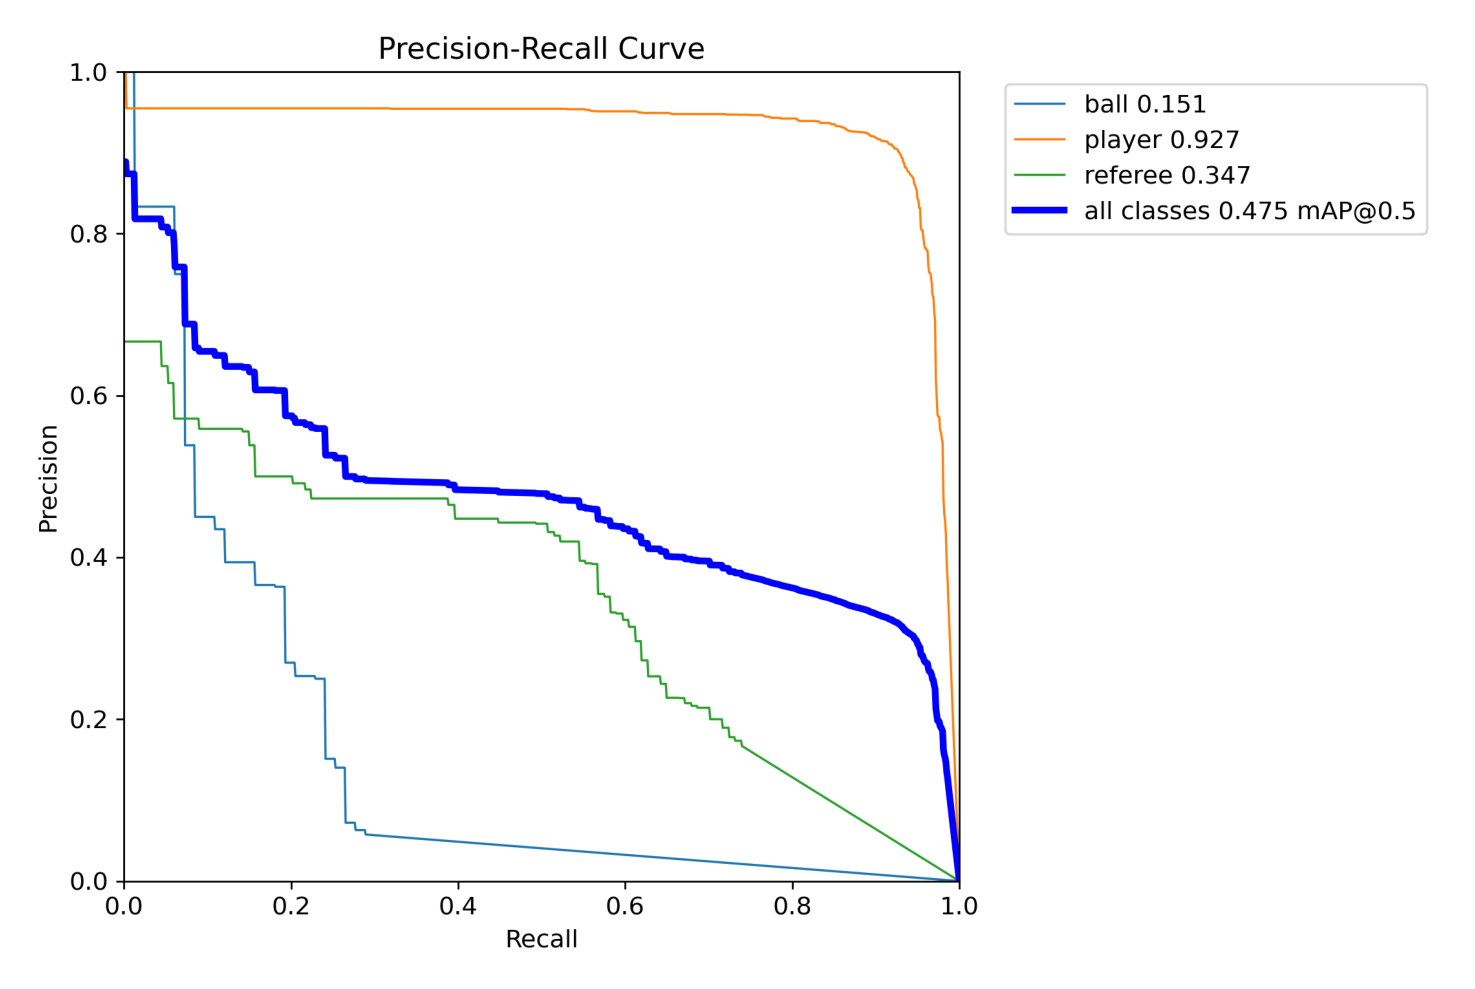

In [6]:
display_image(os.path.join(OBJ_DETECTION_RUN0, "custom_test", "BoxPR_curve.png"))


Aquí se observa, que el modelo es bueno detectando a jugadores, y lo que le lastra son los arbitros y el balon

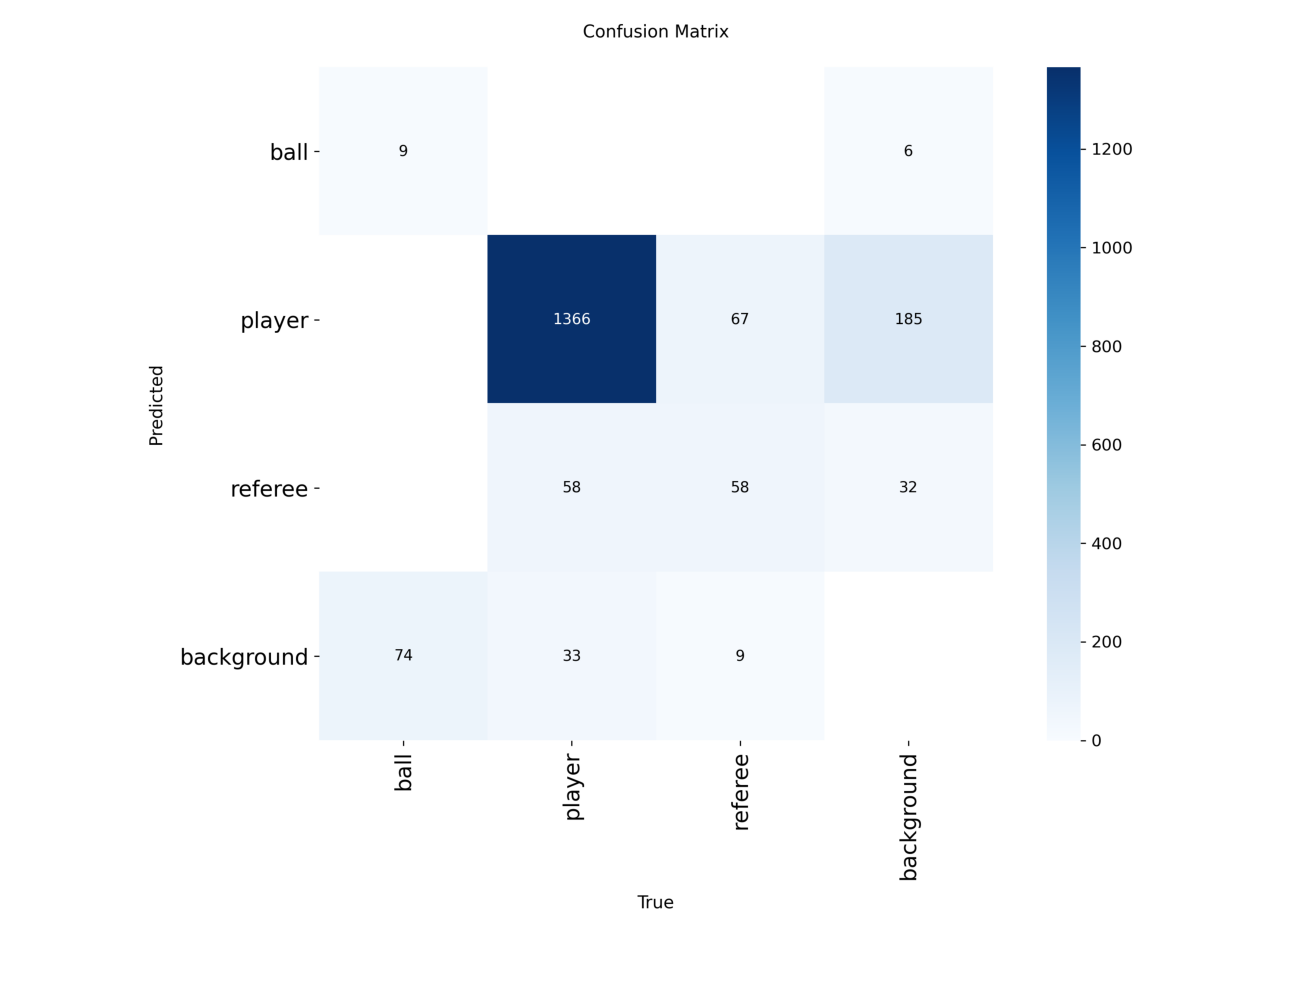

In [7]:
display_image(os.path.join(OBJ_DETECTION_RUN0, "custom_test", "confusion_matrix.png"))


# Iteración 1

* Número imagenes train: $2580 + 256 = 2836$
* Número imágenes val: $300$
* Número imágenes test soccernet : $ 300 $
* Número imágenes test: $ 100 $

In [ ]:
DATA_PATH = "../dataset/object_detection/data.yaml" #Ruta al dataset
OUTPUT_PATH = "models" #Ruta donde se almacena el modelo entrenado

model_1 = YOLO("models/it_0/weights/best.pt")  #Modelo con pesos
model_1.train(
    data=DATA_PATH,
    epochs=100,
    imgsz=640,
    batch=8,
    device=0
)

In [6]:
model_1 = YOLO("models/it_1/weights/best.pt") 

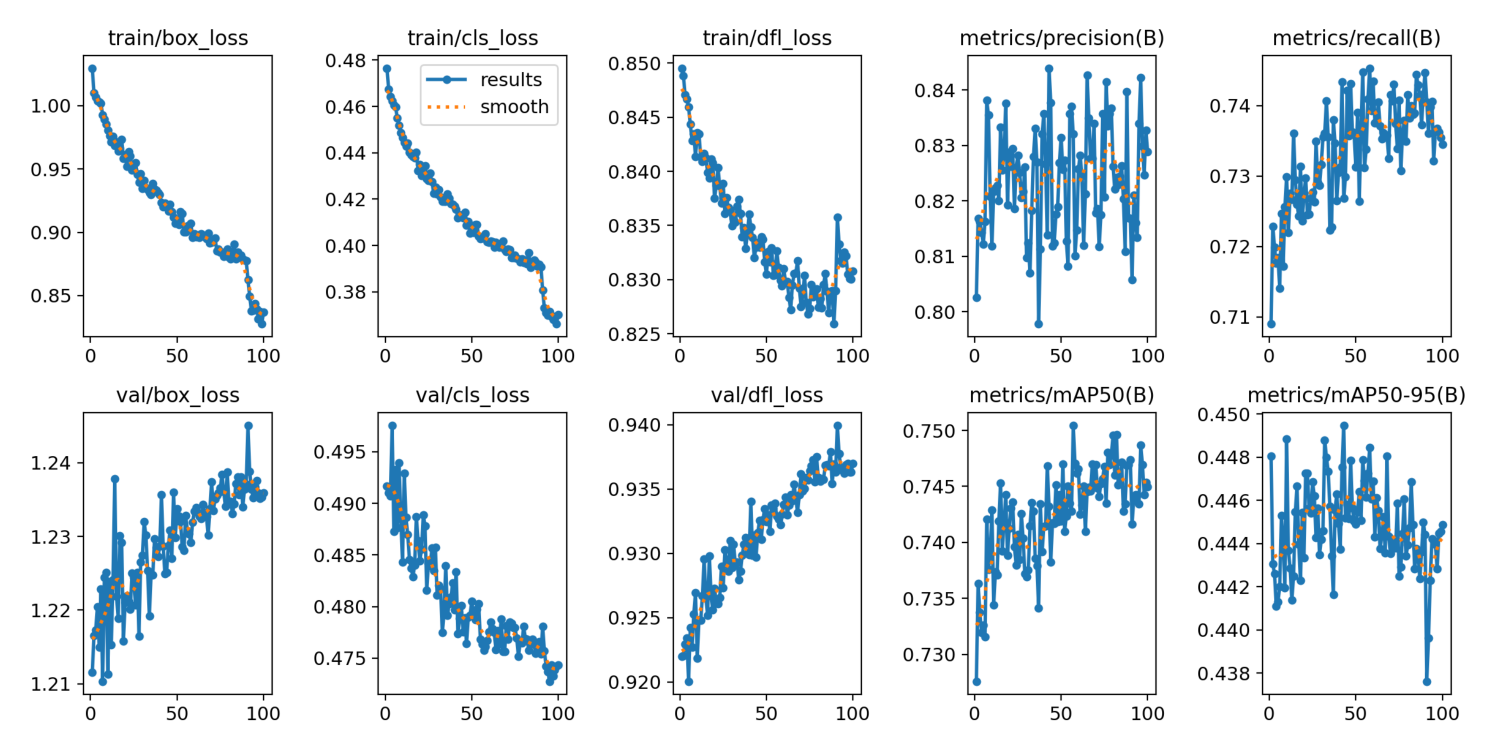

In [8]:
from ia_futbol.utils.config import OBJ_DETECTION_RUN1
display_image(os.path.join(OBJ_DETECTION_RUN1,"results_train.png"))

Al añadir datos nuevos y muy diferentes se producen cambios durante el entrenamiento. 

En relación al box_loss y dfl_loss se produce un sobreaprendizaje; sin embarjo, la clasificación no se ve alterada y parece tener margen de mejora. 


Por otro lado, las metricas se ven alteradas drasticamente produciendo varios picos de mejora como desmejora.


La precision no parece mejorar o tiene un patron claro, mientras que el recall en los ultimos epocs tiene a empeorar. 

Por ultimo, MAP50 si que suele mejorar a diferencia de mAP50-95 que empeora

### Test Soccernet

In [7]:
#TEST SOCCERNET
results_test_soccernet_1= model_1.val(
    data="dataset/test_soccernet.yaml",
    project='results/it_1',
    name='test_soccernet',
    verbose = False
)


Ultralytics 8.3.239 🚀 Python-3.12.2 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6064MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5708.5±1158.4 MB/s, size: 253.0 KB)
val: Scanning /home/adrian/IA-Futbol/object_detection/dataset/test/labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 1.1Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.3it/s 5.7s0.3s
                   all        300       4434      0.779      0.703      0.709       0.44
Speed: 0.5ms preprocess, 16.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/adrian/IA-Futbol/object_detection/results/it_1/test_soccernet2


In [66]:
metrics([results_test_soccernet,results_test_soccernet_1])


,Iteracion0,Iteracion1
mAP50-95,0.440696,0.439592
mAP50,0.699358,0.709145
mAP75,0.491759,0.488166
Precision,0.500719,0.536927
Recall,0.627873,0.610155


La comparación entre Iteración 0 y Iteración 1 muestra cambios leves en el rendimiento, sin mejoras significativas en el mAP global. 

El mAP50-95 se mantiene prácticamente constante (0.4407 → 0.4396), lo que indica que el ajuste realizado en la Iteración 1 no mejora de forma relevante la calidad global de las detecciones. 

El mAP50 presenta una ligera mejora (0.6994 → 0.7091), sugiriendo una mejor detección bajo criterios de solapamiento menos exigentes, mientras que el mAP75 disminuye ligeramente, lo que apunta a una leve pérdida de precisión en la localización de las bounding boxes más ajustadas.

En cuanto a precisión y recall, se observa un incremento notable de la precisión (0.5007 → 0.5369), acompañado de una ligera caída del recall (0.6279 → 0.6102). Esto sugiere que el modelo de la Iteración 1 adopta un comportamiento más conservador, reduciendo falsos positivos a costa de dejar escapar algunas detecciones.

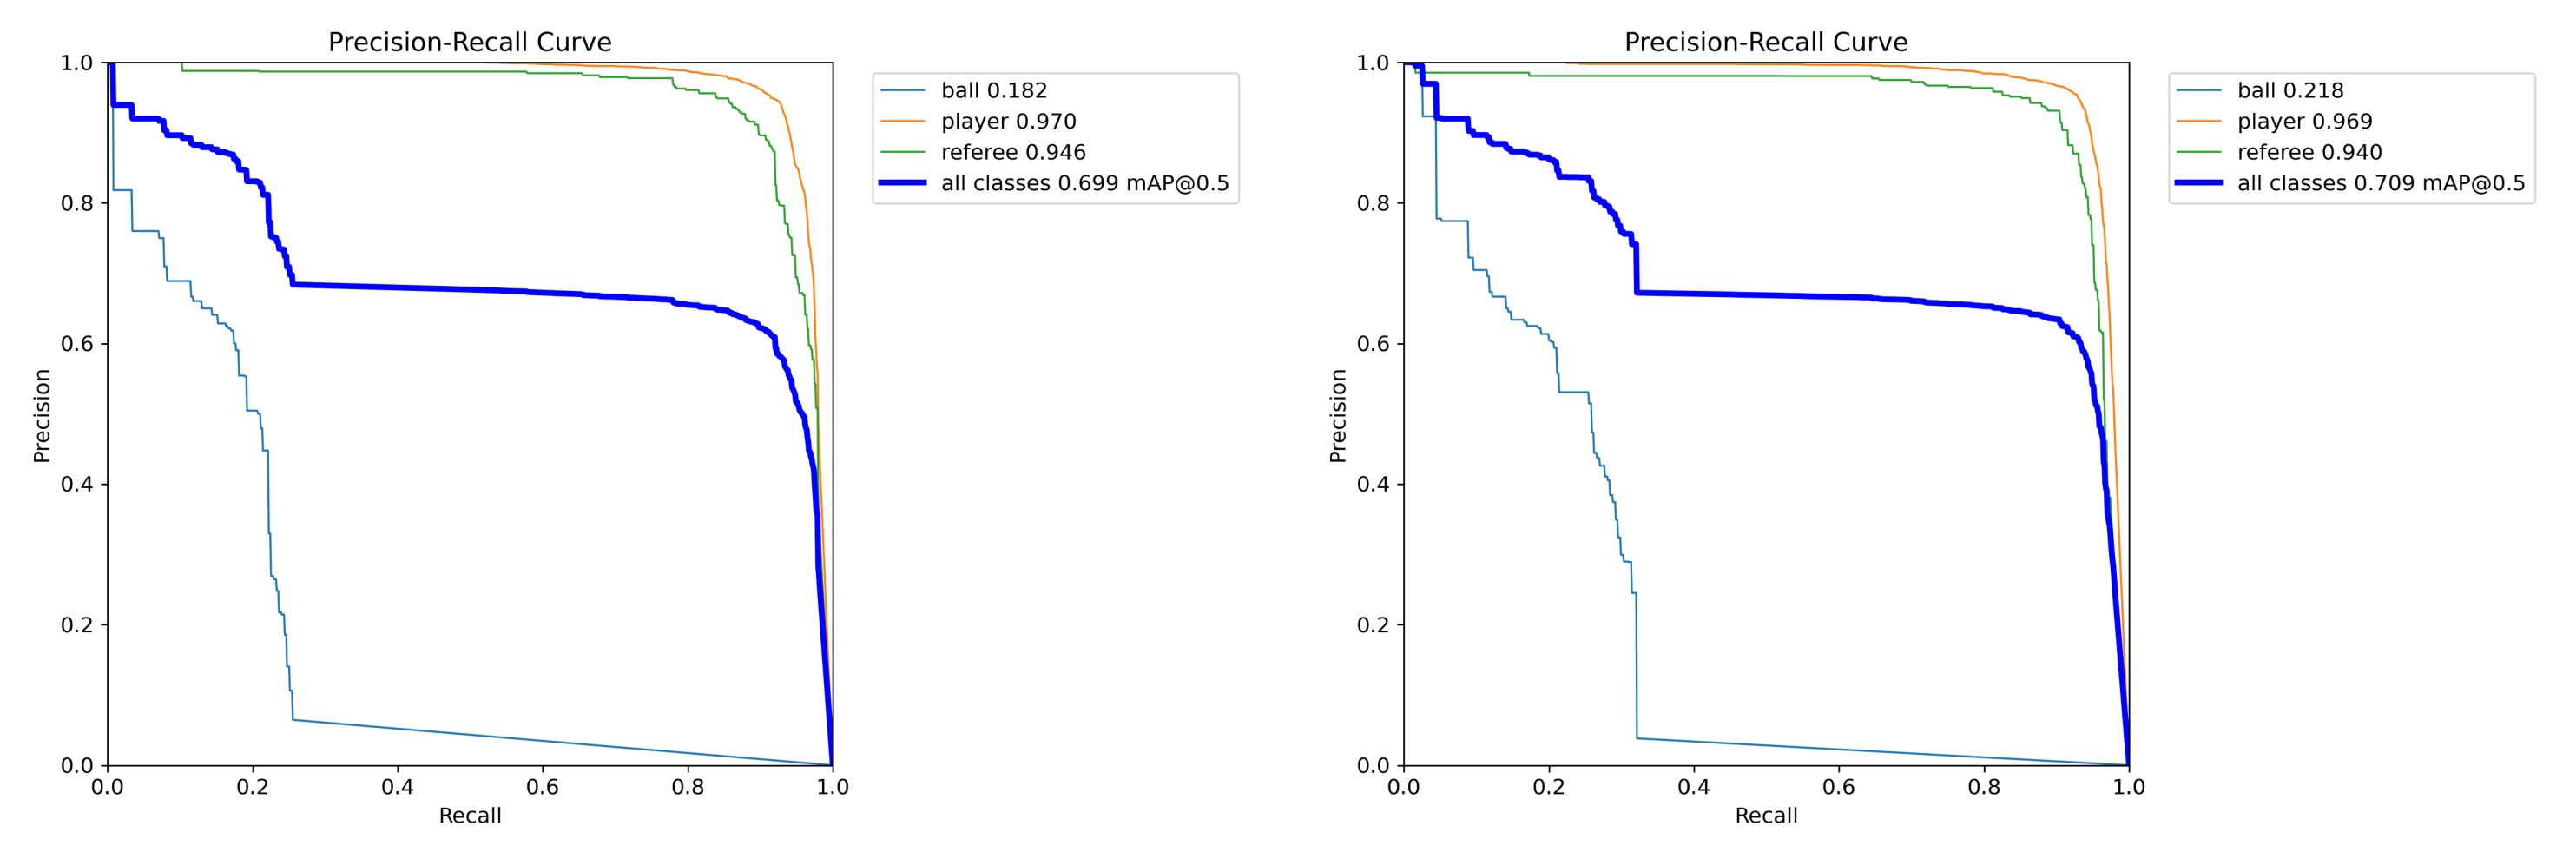

In [9]:
boxpr_it_0 = os.path.join(OBJ_DETECTION_RUN0,"soccernet_test","BoxPR_curve.png")
boxpr_it_1 = os.path.join(OBJ_DETECTION_RUN1,"soccernet_test","BoxPR_curve.png")

display_image([boxpr_it_0,boxpr_it_1])

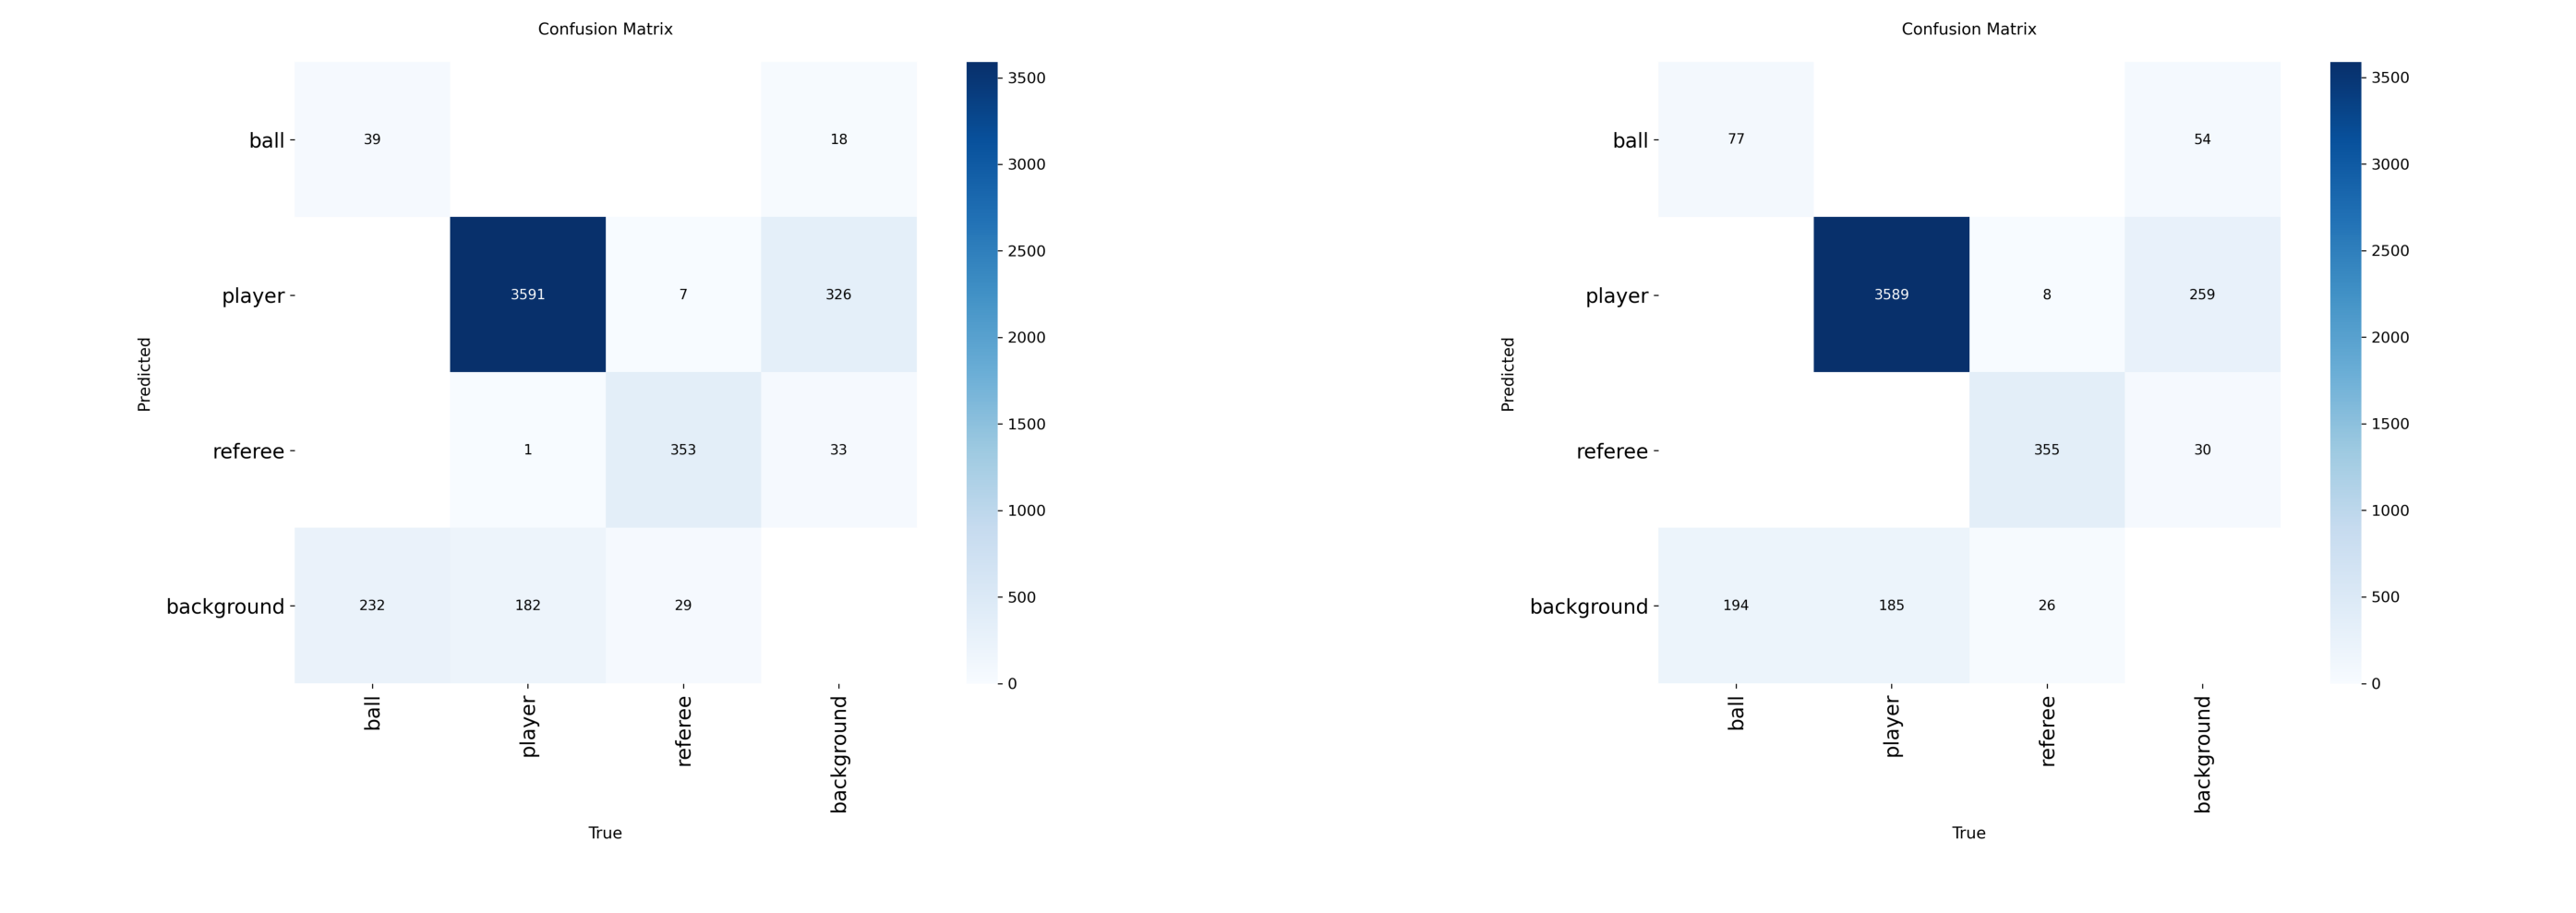

In [10]:
confusion_matrix_it_0 = os.path.join(OBJ_DETECTION_RUN0,"soccernet_test","confusion_matrix.png")
confusion_matrix_it_1 = os.path.join(OBJ_DETECTION_RUN1,"soccernet_test","confusion_matrix.png")

display_image([confusion_matrix_it_0,confusion_matrix_it_1])

### Test Propio

In [8]:
results_new_test_1= model_1.val(
    data="dataset/test.yaml",
    project='results/it_1',
    name='new_test')

Ultralytics 8.3.239 🚀 Python-3.12.2 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6064MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4131.7±2317.8 MB/s, size: 461.1 KB)
val: Scanning /home/adrian/IA-Futbol/object_detection/dataset/new_test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 402.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.2it/s 2.2s0.4s
                   all        100       1674      0.904      0.708      0.767      0.554
                  ball         83         83      0.882      0.349      0.431      0.168
                player        100       1457       0.94      0.974      0.976      0.801
               referee         86        134      0.892        0.8      0.892      0.694
Speed: 1.0ms preprocess, 16.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /home/adrian/IA-Futbol/object_detection/results/it_1/new_test2

In [92]:
metrics([results_new_test,results_new_test_1])

,Iteracion0,Iteracion1
mAP50-95,0.287972,0.554392
mAP50,0.475340,0.766528
mAP75,0.322608,0.589997
Precision,0.369703,0.525713
Recall,0.459036,0.587534


La comparación entre Iteración 0 y Iteración 1 muestra una mejora muy significativa del rendimiento en el conjunto propio, lo que indica un avance claro en la capacidad de generalización del modelo. 

El mAP50-95 prácticamente se duplica (0.288 → 0.554), evidenciando una mejora sustancial tanto en la detección como en la precisión de localización de los objetos. Esta tendencia se refleja también en el mAP50 (0.475 → 0.767) y en el mAP75 (0.323 → 0.590), lo que confirma que el modelo no solo detecta más objetos, sino que lo hace con bounding boxes considerablemente más ajustadas.

En términos de precisión y recall, ambos métricos aumentan de forma notable. La precisión pasa de 0.37 a 0.53, reduciendo significativamente el número de falsos positivos, mientras que el recall aumenta de 0.46 a 0.59, indicando que el modelo es capaz de detectar una mayor proporción de los objetos presentes. Este incremento simultáneo sugiere una mejora real del modelo y no un simple cambio en el umbral de decisión.

La incorporación de nuevas imágenes procedentes de distintas ligas y condiciones, diferentes a las de SoccerNet, ha tenido un impacto claramente positivo.

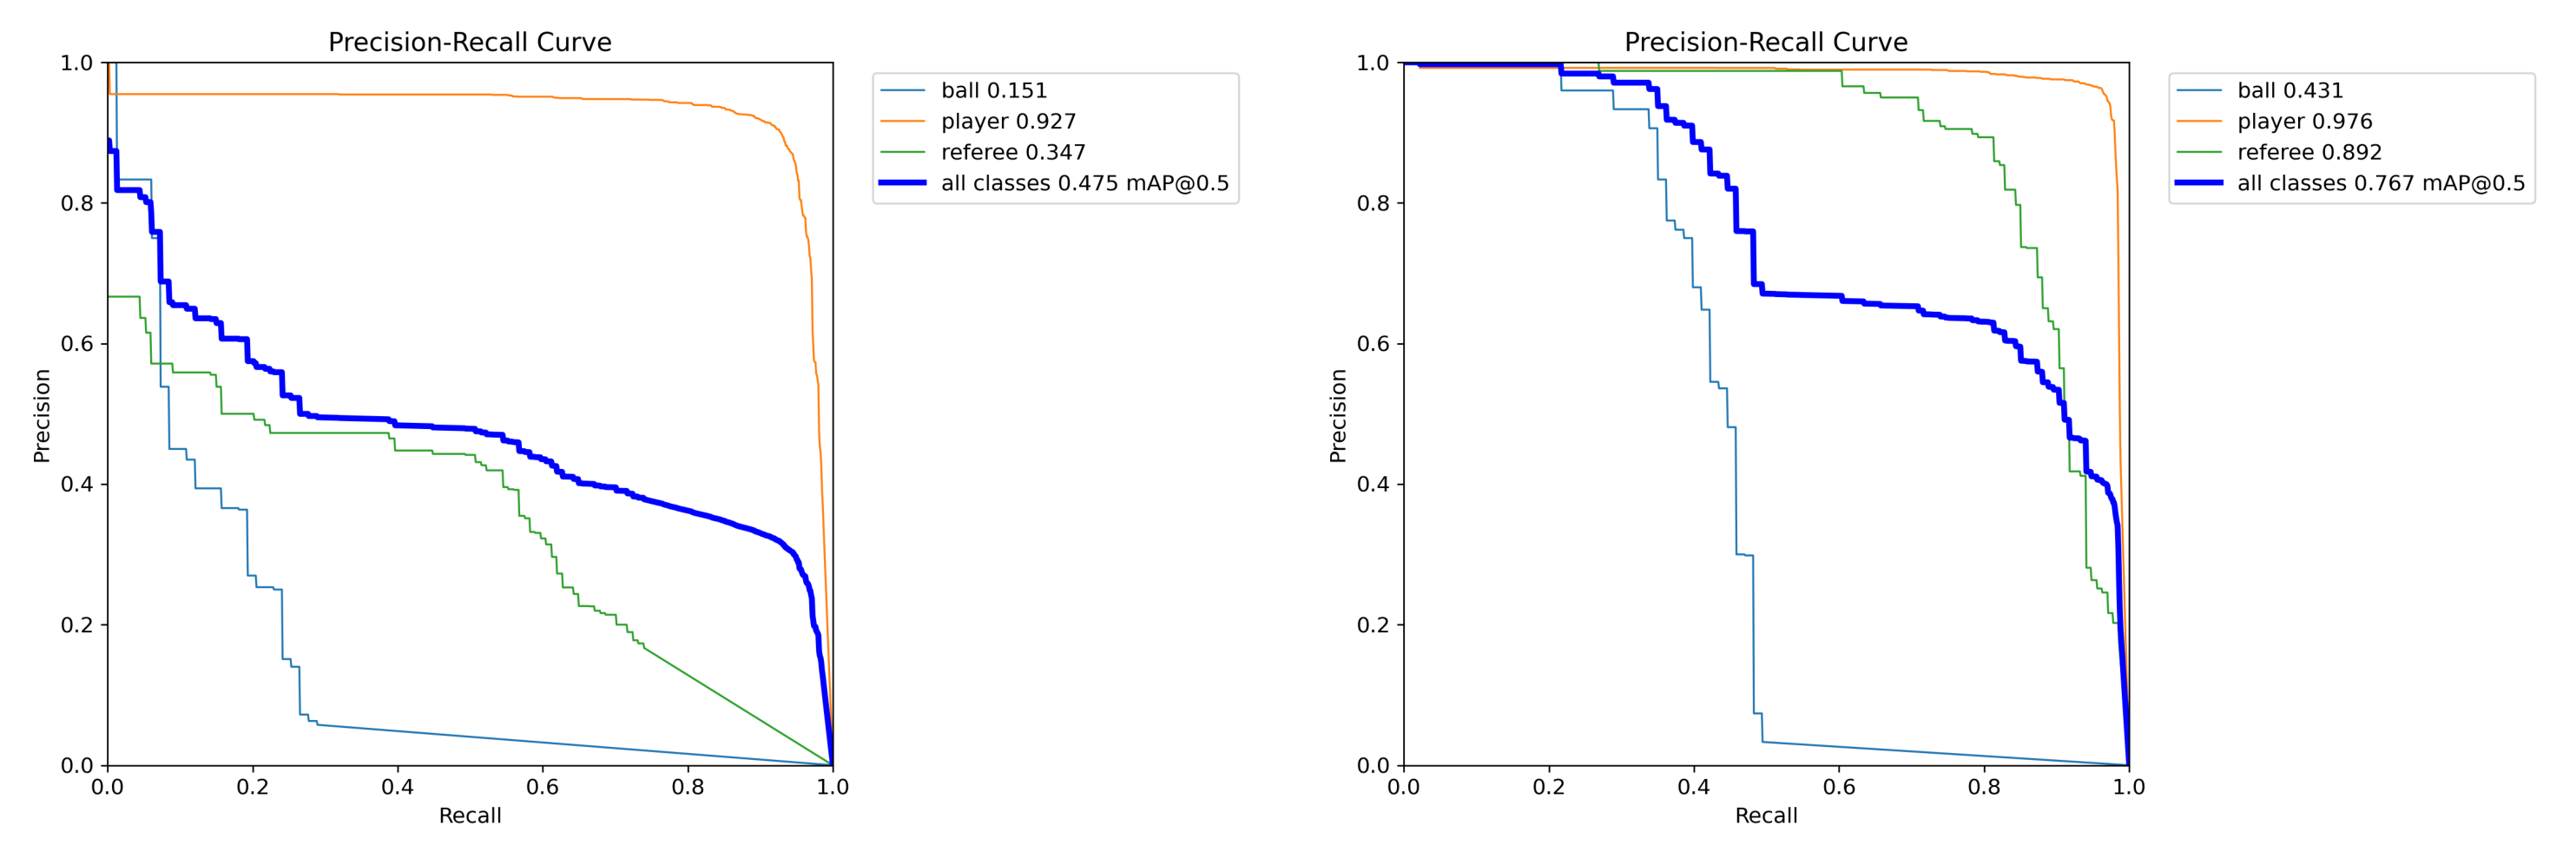

In [11]:
boxpr_it_0 = os.path.join(OBJ_DETECTION_RUN0,"custom_test","BoxPR_curve.png")
boxpr_it_1 = os.path.join(OBJ_DETECTION_RUN1,"custom_test","BoxPR_curve.png")

display_image([boxpr_it_0,boxpr_it_1])

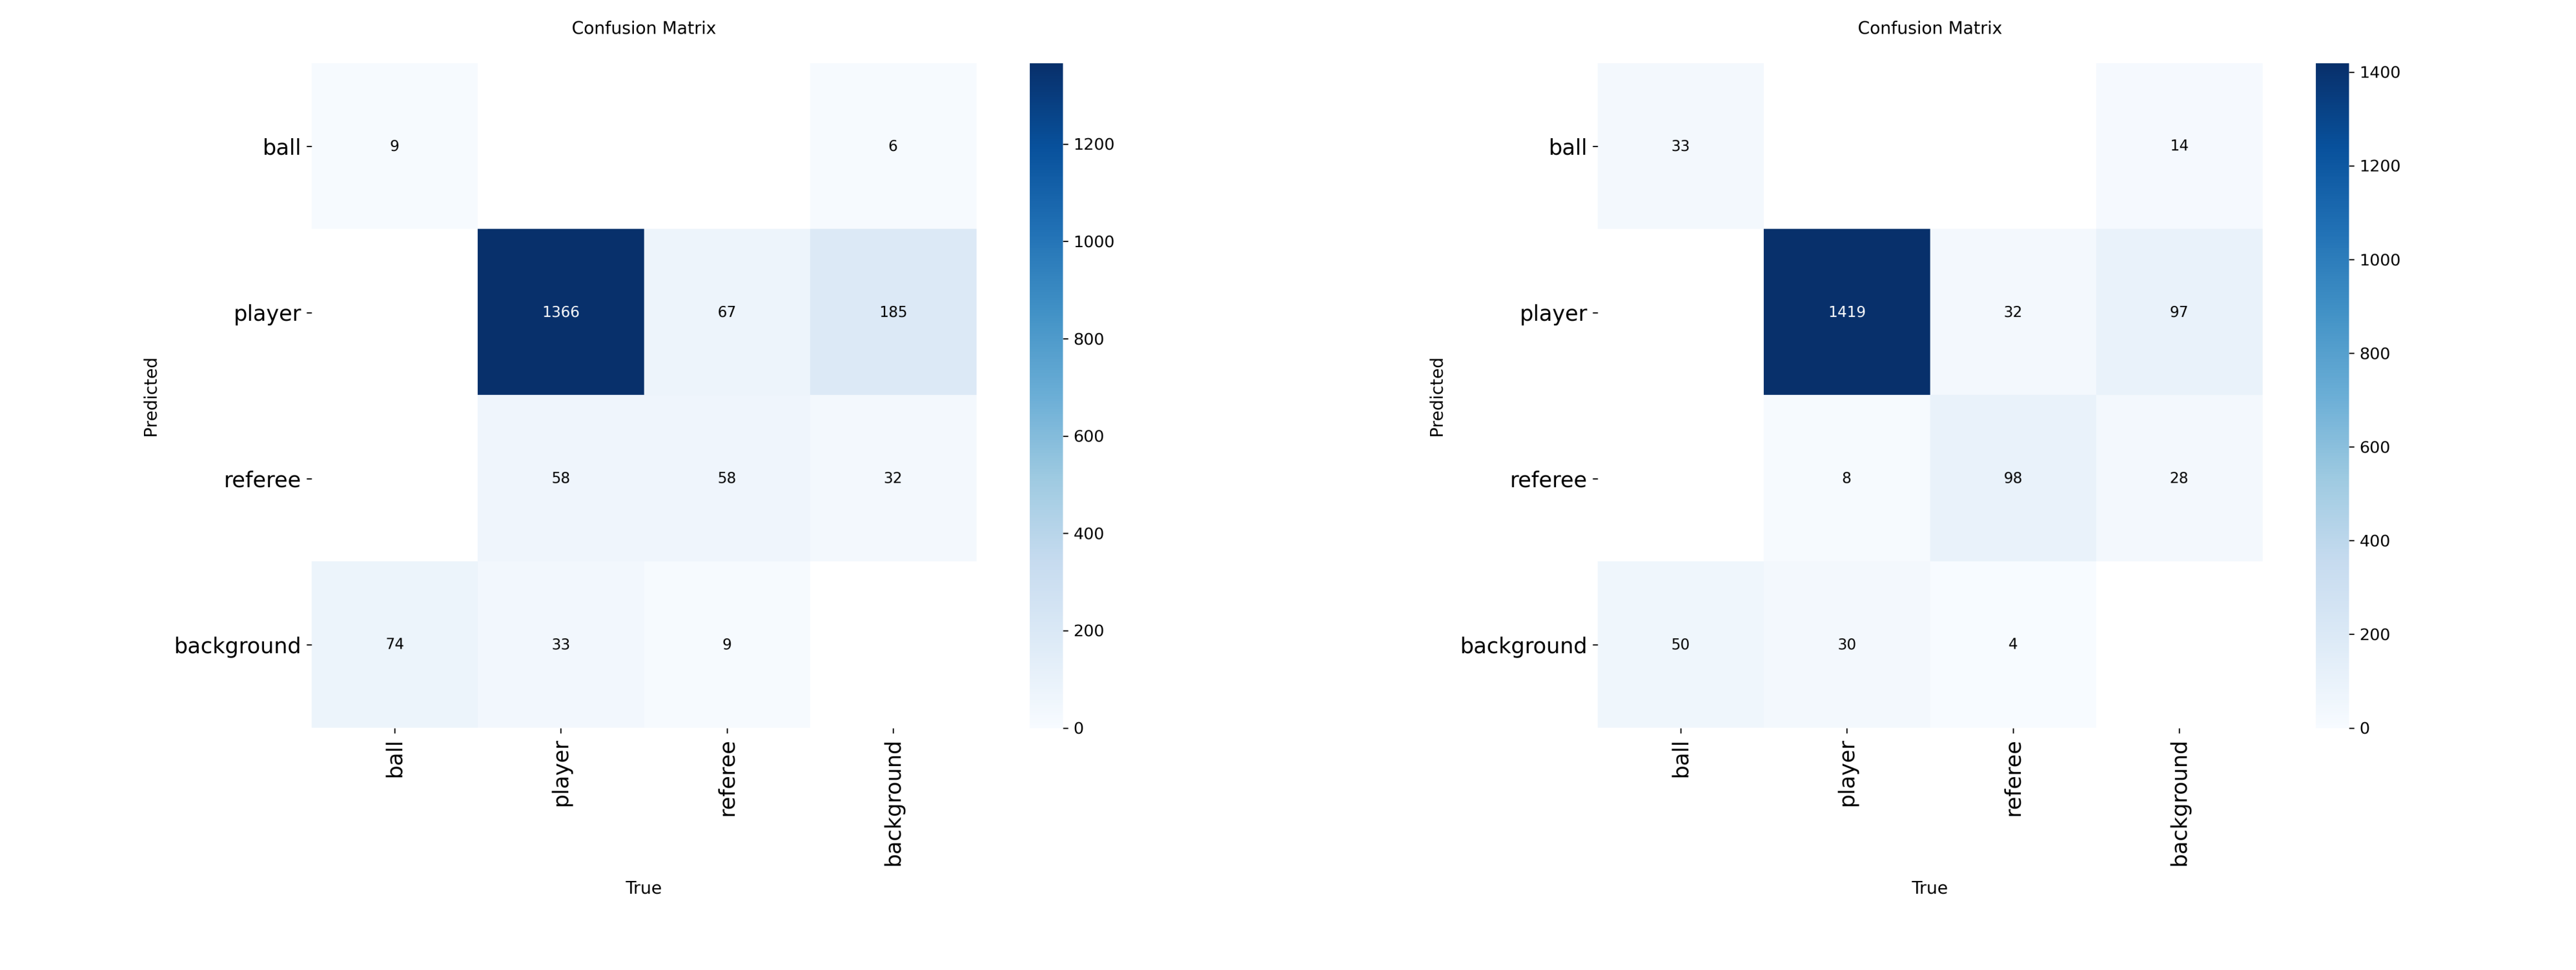

In [22]:
confusion_matrix_it_0 = os.path.join(OBJ_DETECTION_RUN0,"custom_test","confusion_matrix.png")
confusion_matrix_it_1 = os.path.join(OBJ_DETECTION_RUN1,"custom_test","confusion_matrix.png")

display_image([confusion_matrix_it_0,confusion_matrix_it_1],figsize=(20,20))

# Iteración 2

* Número imagenes train: $2836 + 257 = 3093$
* Número imágenes val: $300$
* Número imágenes test soccernet : $ 300 $
* Número imágenes test: $ 100 $

In [ ]:
DATA_PATH = "../dataset/object_detection/data.yaml" #Ruta al dataset
OUTPUT_PATH = "models" #Ruta donde se almacena el modelo entrenado

model_2= YOLO("models/it_1/weights/best.pt")  #Modelo con pesos
model_2.train(
    data=DATA_PATH,
    epochs=100,
    imgsz=640,
    batch=8,
    device=0
)

In [9]:
model_2= YOLO("models/it_2/weights/best.pt")  

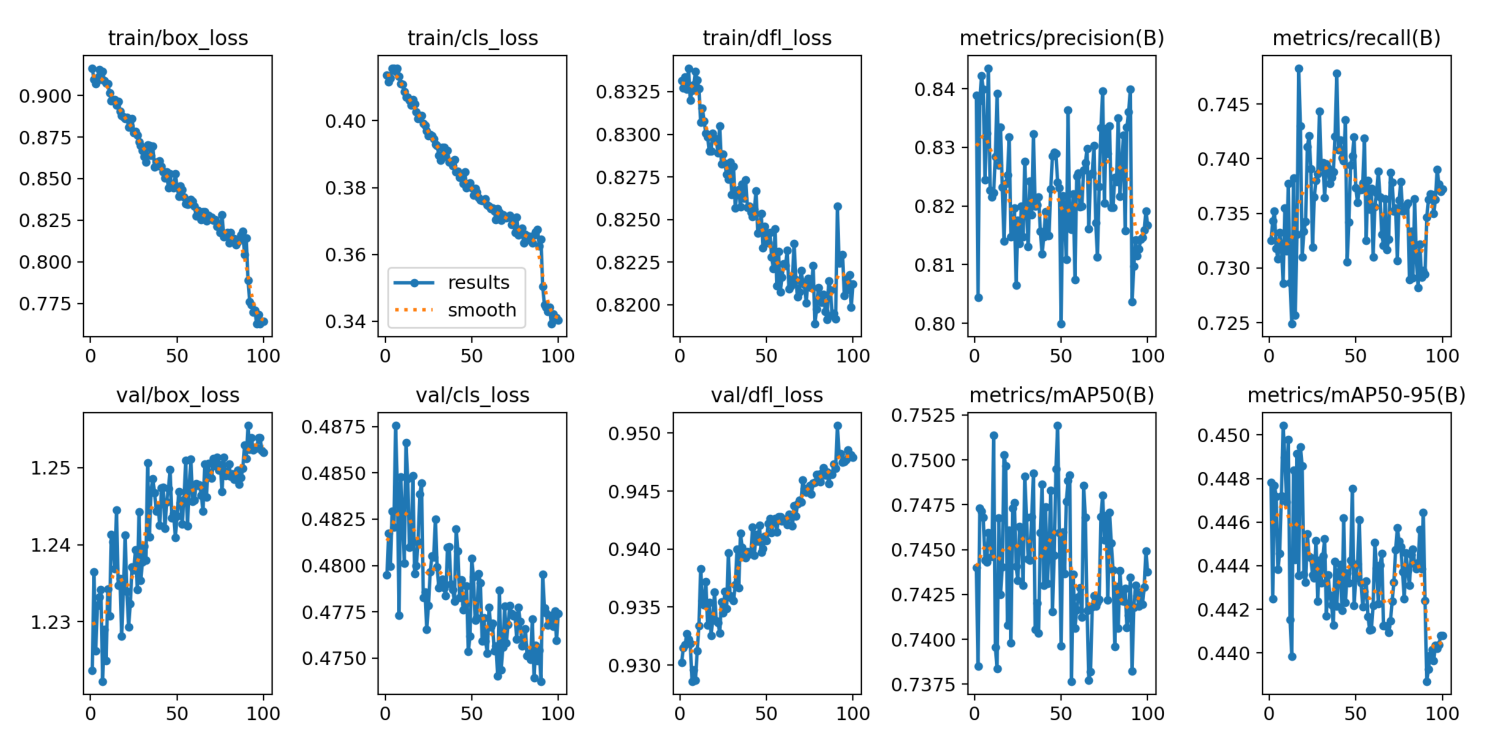

In [23]:
from ia_futbol.utils.config import OBJ_DETECTION_RUN2
display_image(os.path.join(OBJ_DETECTION_RUN2,"results_train.png"))

### Test Soccernet

In [13]:
#TEST SOCCERNET
results_test_soccernet_2= model_2.val(
    data="dataset/test_soccernet.yaml",
    project='results/it_2',
    name='test_soccernet',
    verbose = False
)


Ultralytics 8.3.239 🚀 Python-3.12.2 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6064MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6048.0±2705.9 MB/s, size: 222.8 KB)
val: Scanning /home/adrian/IA-Futbol/object_detection/dataset/test/labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 945.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.3it/s 5.7s0.3s
                   all        300       4434      0.776      0.707       0.71       0.44
Speed: 0.5ms preprocess, 16.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/adrian/IA-Futbol/object_detection/results/it_2/test_soccernet


In [14]:
metrics([results_test_soccernet,results_test_soccernet_1,results_test_soccernet_2])

,Iteracion0,Iteracion1,Iteracion2
mAP50-95,0.440696,0.439592,0.440353
mAP50,0.699358,0.709145,0.710229
mAP75,0.491759,0.488166,0.487490
Precision,0.500719,0.536927,0.536633
Recall,0.627873,0.610155,0.601690


El rendimiento se mantiene estable a lo largo de las tres iteraciones. 

El mAP50-95 apenas varía, lo que indica que las modificaciones introducidas no afectan de forma significativa al rendimiento global. 

Se observa una ligera mejora en mAP50 y precisión, acompañada de una disminución progresiva del recall ,lo que sugiere un modelo cada vez más conservador: reduce falsos positivos, pero a costa de perder algunas detecciones y sin mejorar la precisión en la localización fina. 

En conjunto, no se aprecian mejoras sustanciales en SoccerNet, lo que indica que los cambios no aportan beneficios claros en este conjunto.

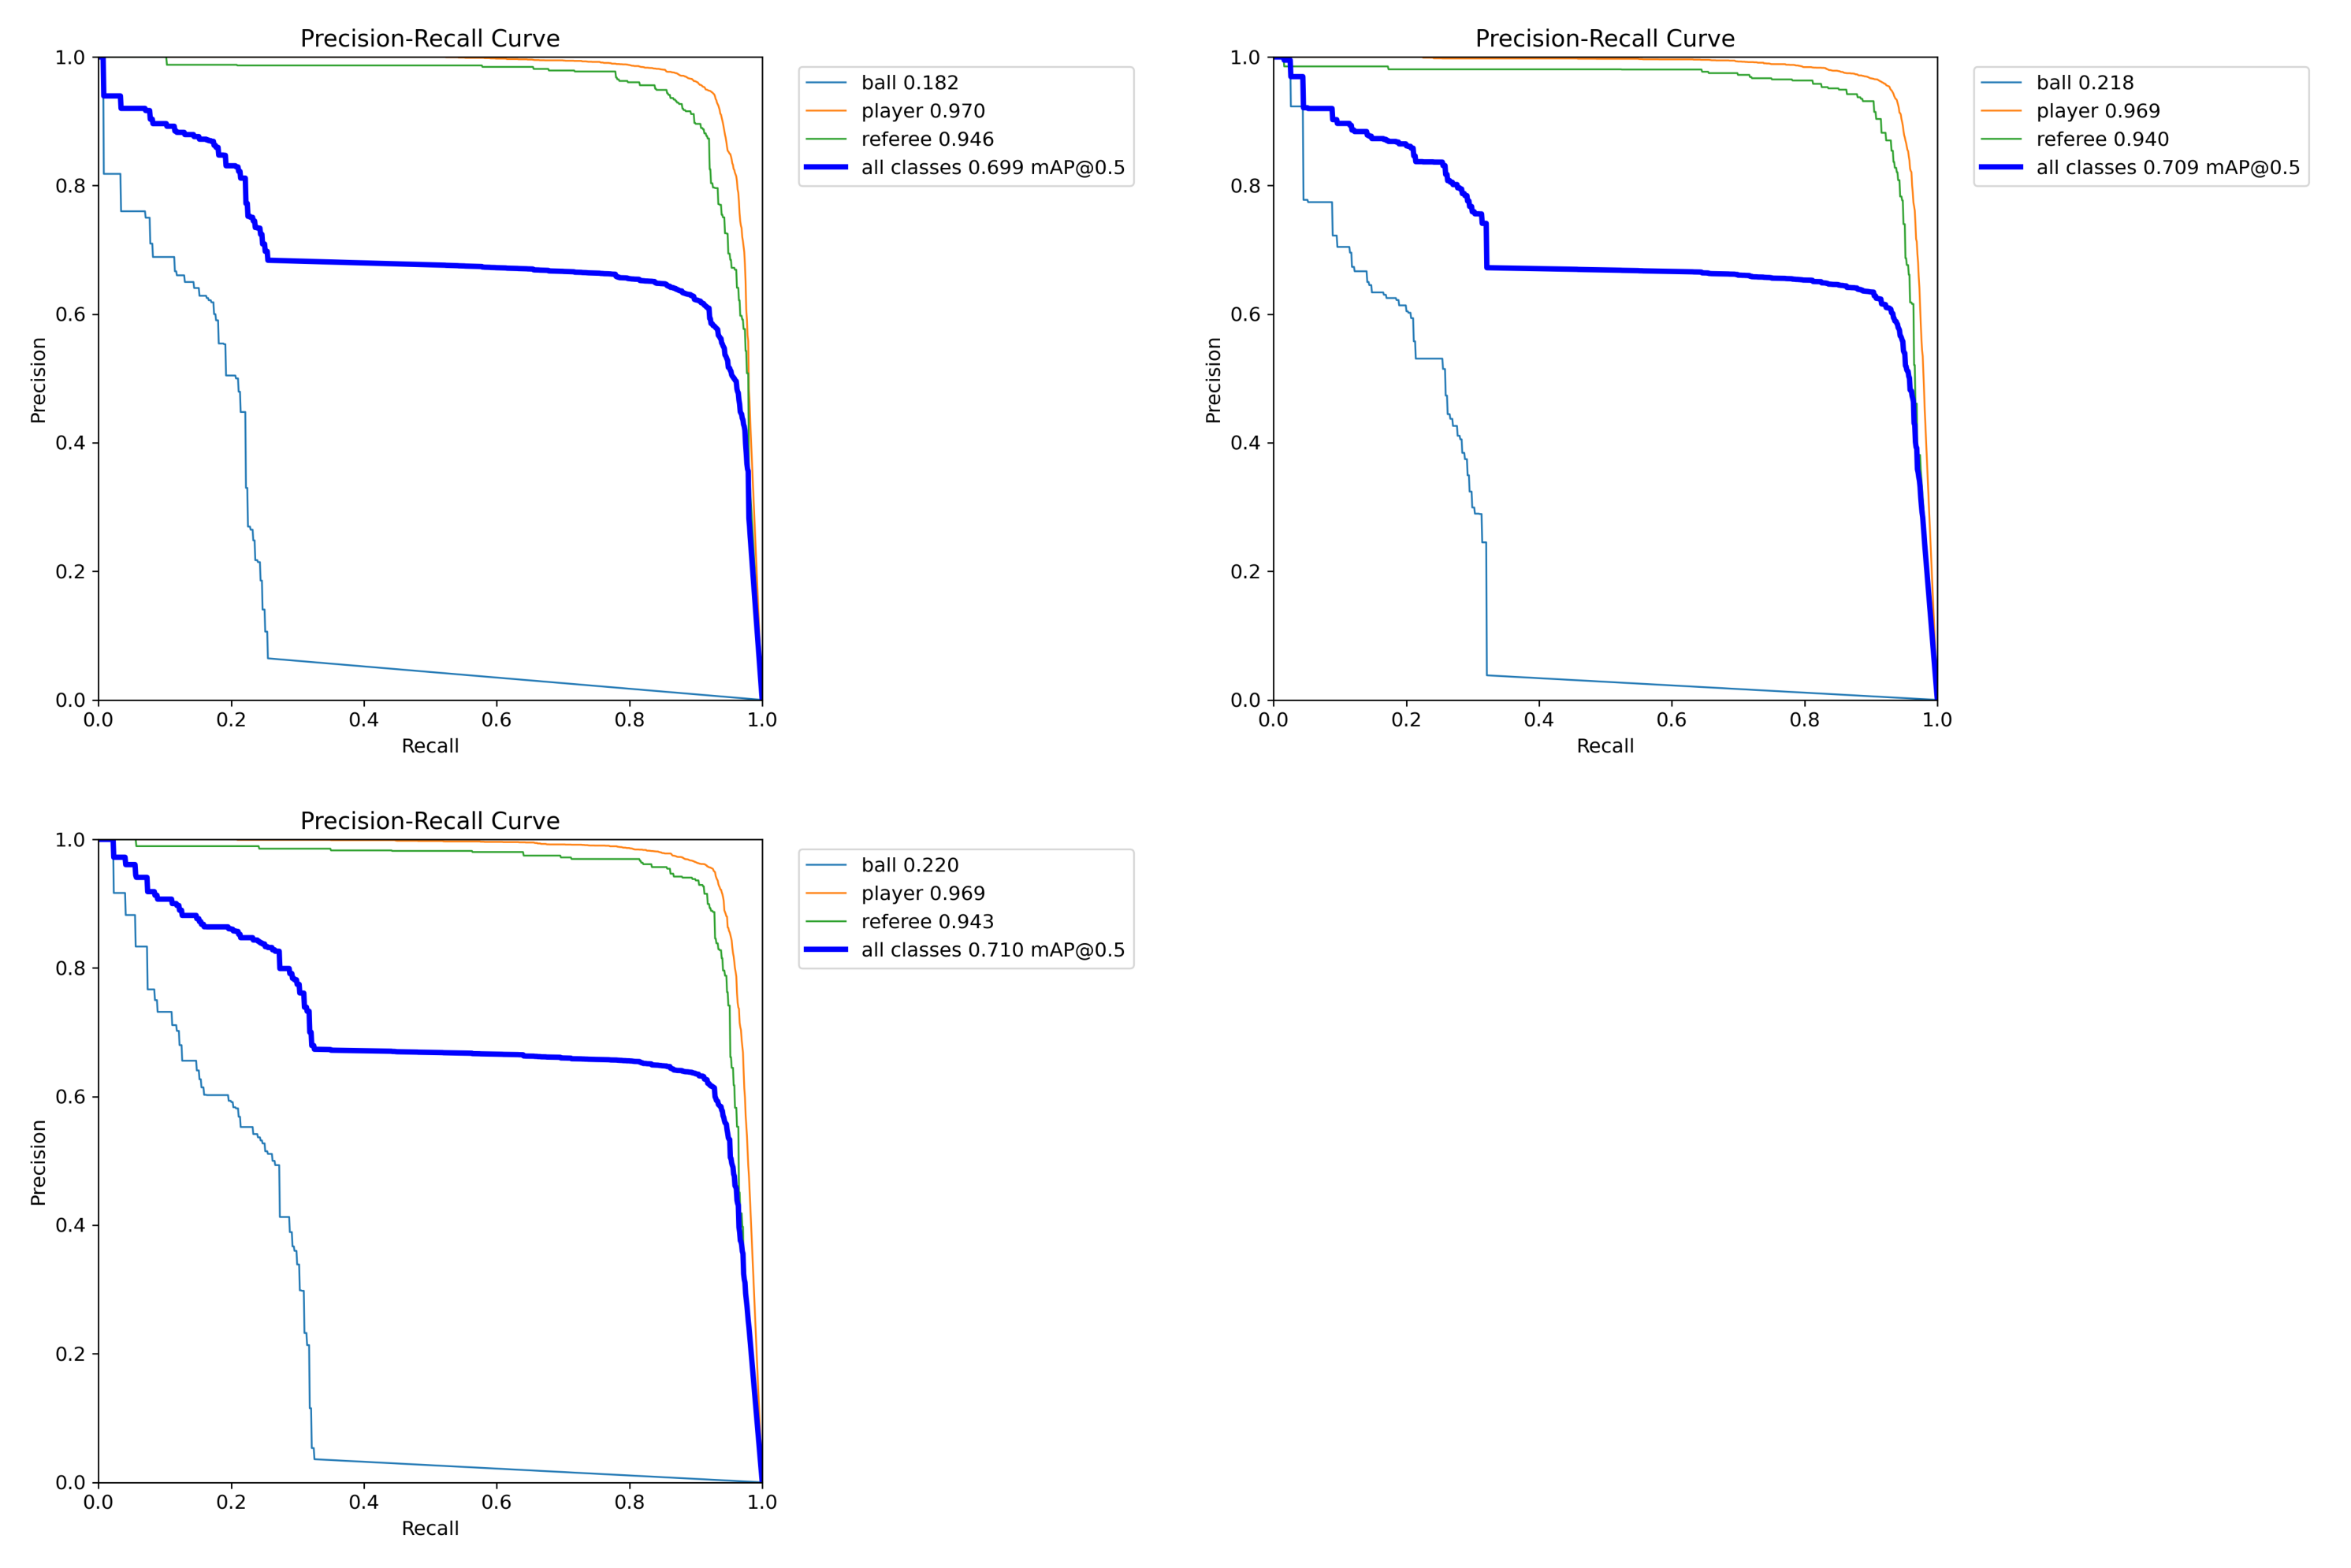

In [24]:
from ia_futbol.utils.config import OBJ_DETECTION_RUN2
boxpr_it_0 = os.path.join(OBJ_DETECTION_RUN0,"soccernet_test","BoxPR_curve.png")
boxpr_it_1 = os.path.join(OBJ_DETECTION_RUN1,"soccernet_test","BoxPR_curve.png")
boxpr_it_2 = os.path.join(OBJ_DETECTION_RUN2,"soccernet_test","BoxPR_curve.png")

display_image([boxpr_it_0,boxpr_it_1,boxpr_it_2])

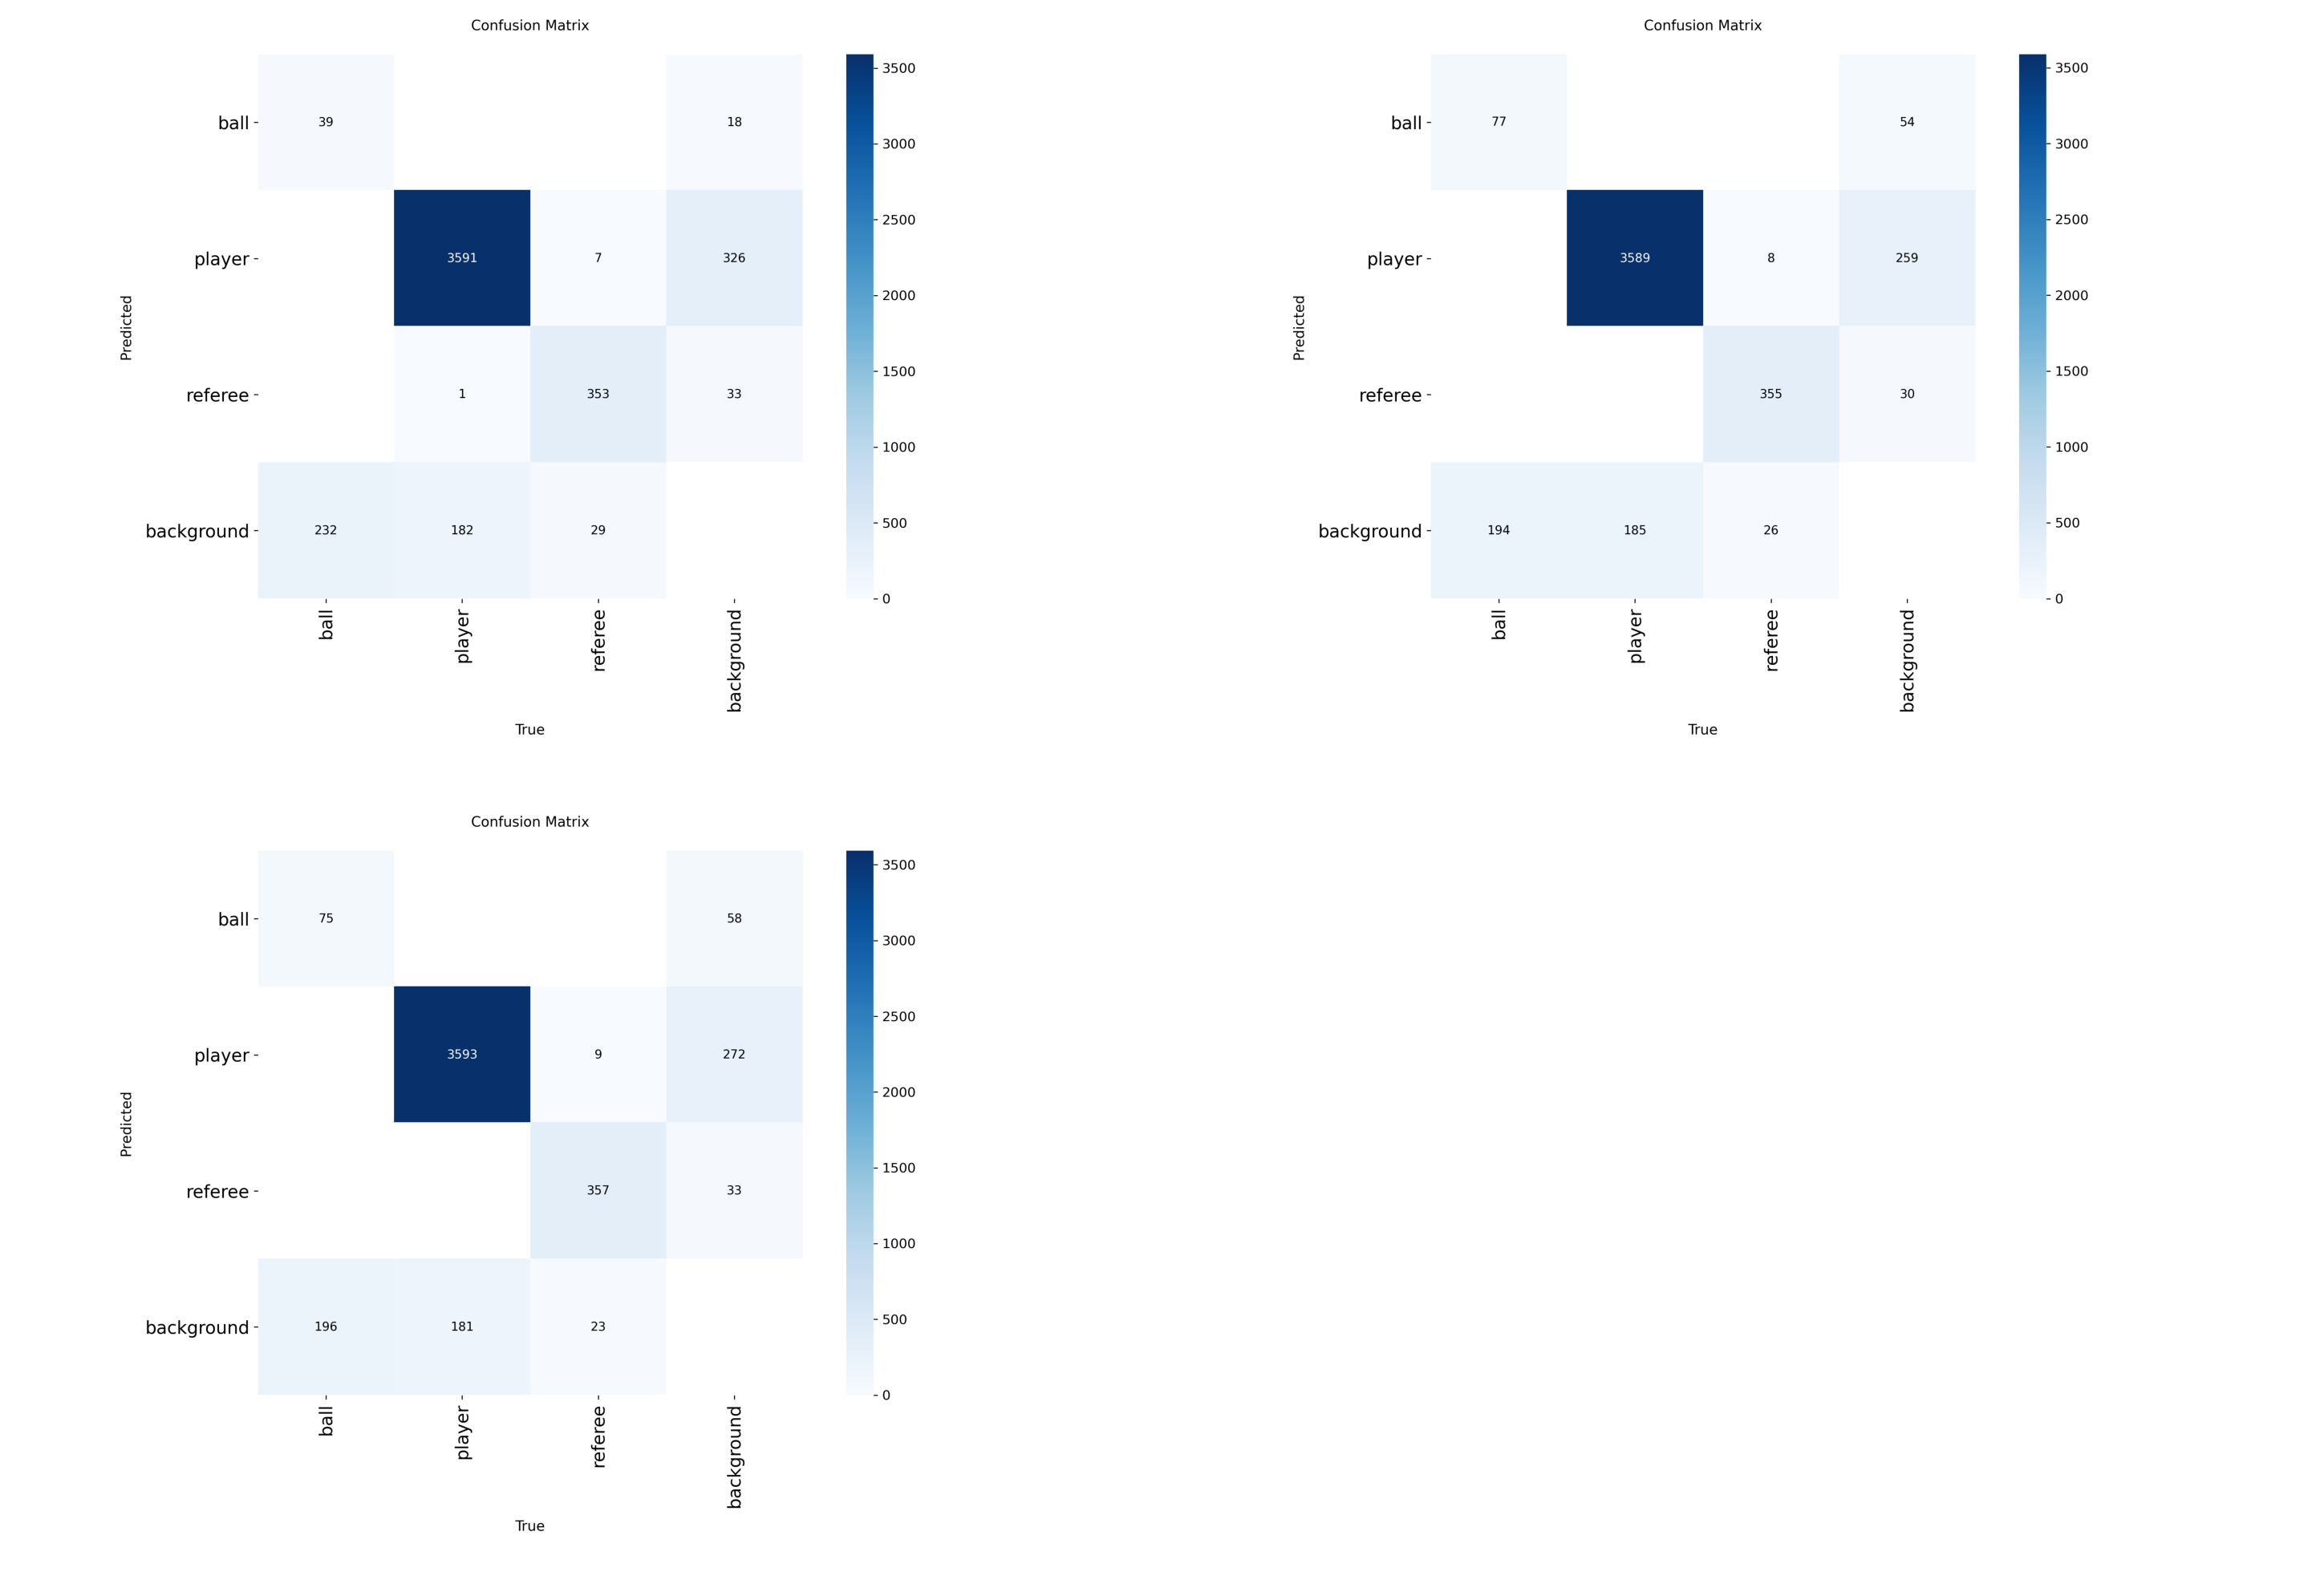

In [25]:
confusion_matrix_it_0 = os.path.join(OBJ_DETECTION_RUN0,"soccernet_test","confusion_matrix.png")
confusion_matrix_it_1 = os.path.join(OBJ_DETECTION_RUN1,"soccernet_test","confusion_matrix.png")
confusion_matrix_it_2 = os.path.join(OBJ_DETECTION_RUN2,"soccernet_test","confusion_matrix.png")

display_image([confusion_matrix_it_0,confusion_matrix_it_1,confusion_matrix_it_2])

### Test Propio

In [20]:
results_new_test_2= model_2.val(
    data="dataset/test.yaml",
    project='results/it_2',
    name='new_test')

Ultralytics 8.3.239 🚀 Python-3.12.2 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6064MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5251.1±2157.3 MB/s, size: 336.3 KB)
val: Scanning /home/adrian/IA-Futbol/object_detection/dataset/new_test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 267.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.2it/s 2.2s0.3ss
                   all        100       1674      0.901       0.73      0.778       0.58
                  ball         83         83      0.866      0.386      0.435      0.194
                player        100       1457      0.947      0.976      0.982      0.812
               referee         86        134      0.888      0.828      0.917      0.734
Speed: 1.1ms preprocess, 16.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /home/adrian/IA-Futbol/object_detection/results/it_2/new_test

In [21]:
metrics([results_new_test,results_new_test_1,results_new_test_2])

,Iteracion0,Iteracion1,Iteracion2
mAP50-95,0.287972,0.554392,0.579749
mAP50,0.475340,0.766528,0.777807
mAP75,0.322608,0.589997,0.614323
Precision,0.369703,0.525713,0.543822
Recall,0.459036,0.587534,0.593190


Se muestra una mejora consistente, aunque más moderada que en la iteración anterior. 

El mAP50-95 aumenta (0.55 → 0.58), junto con mejoras en mAP50 y mAP75, lo que indica una mayor calidad en la detección y una localización más precisa de los objetos. 


Asimismo, se observa un incremento tanto en precisión como en recall, sugiriendo un mejor equilibrio entre reducción de falsos positivos y capacidad de detección.

En general, los resultados confirman una tendencia positiva y estable en el conjunto propio, evidenciando que el modelo continúa beneficiándose de la diversidad del dataset y mejora su capacidad de generalización en escenarios más variados.

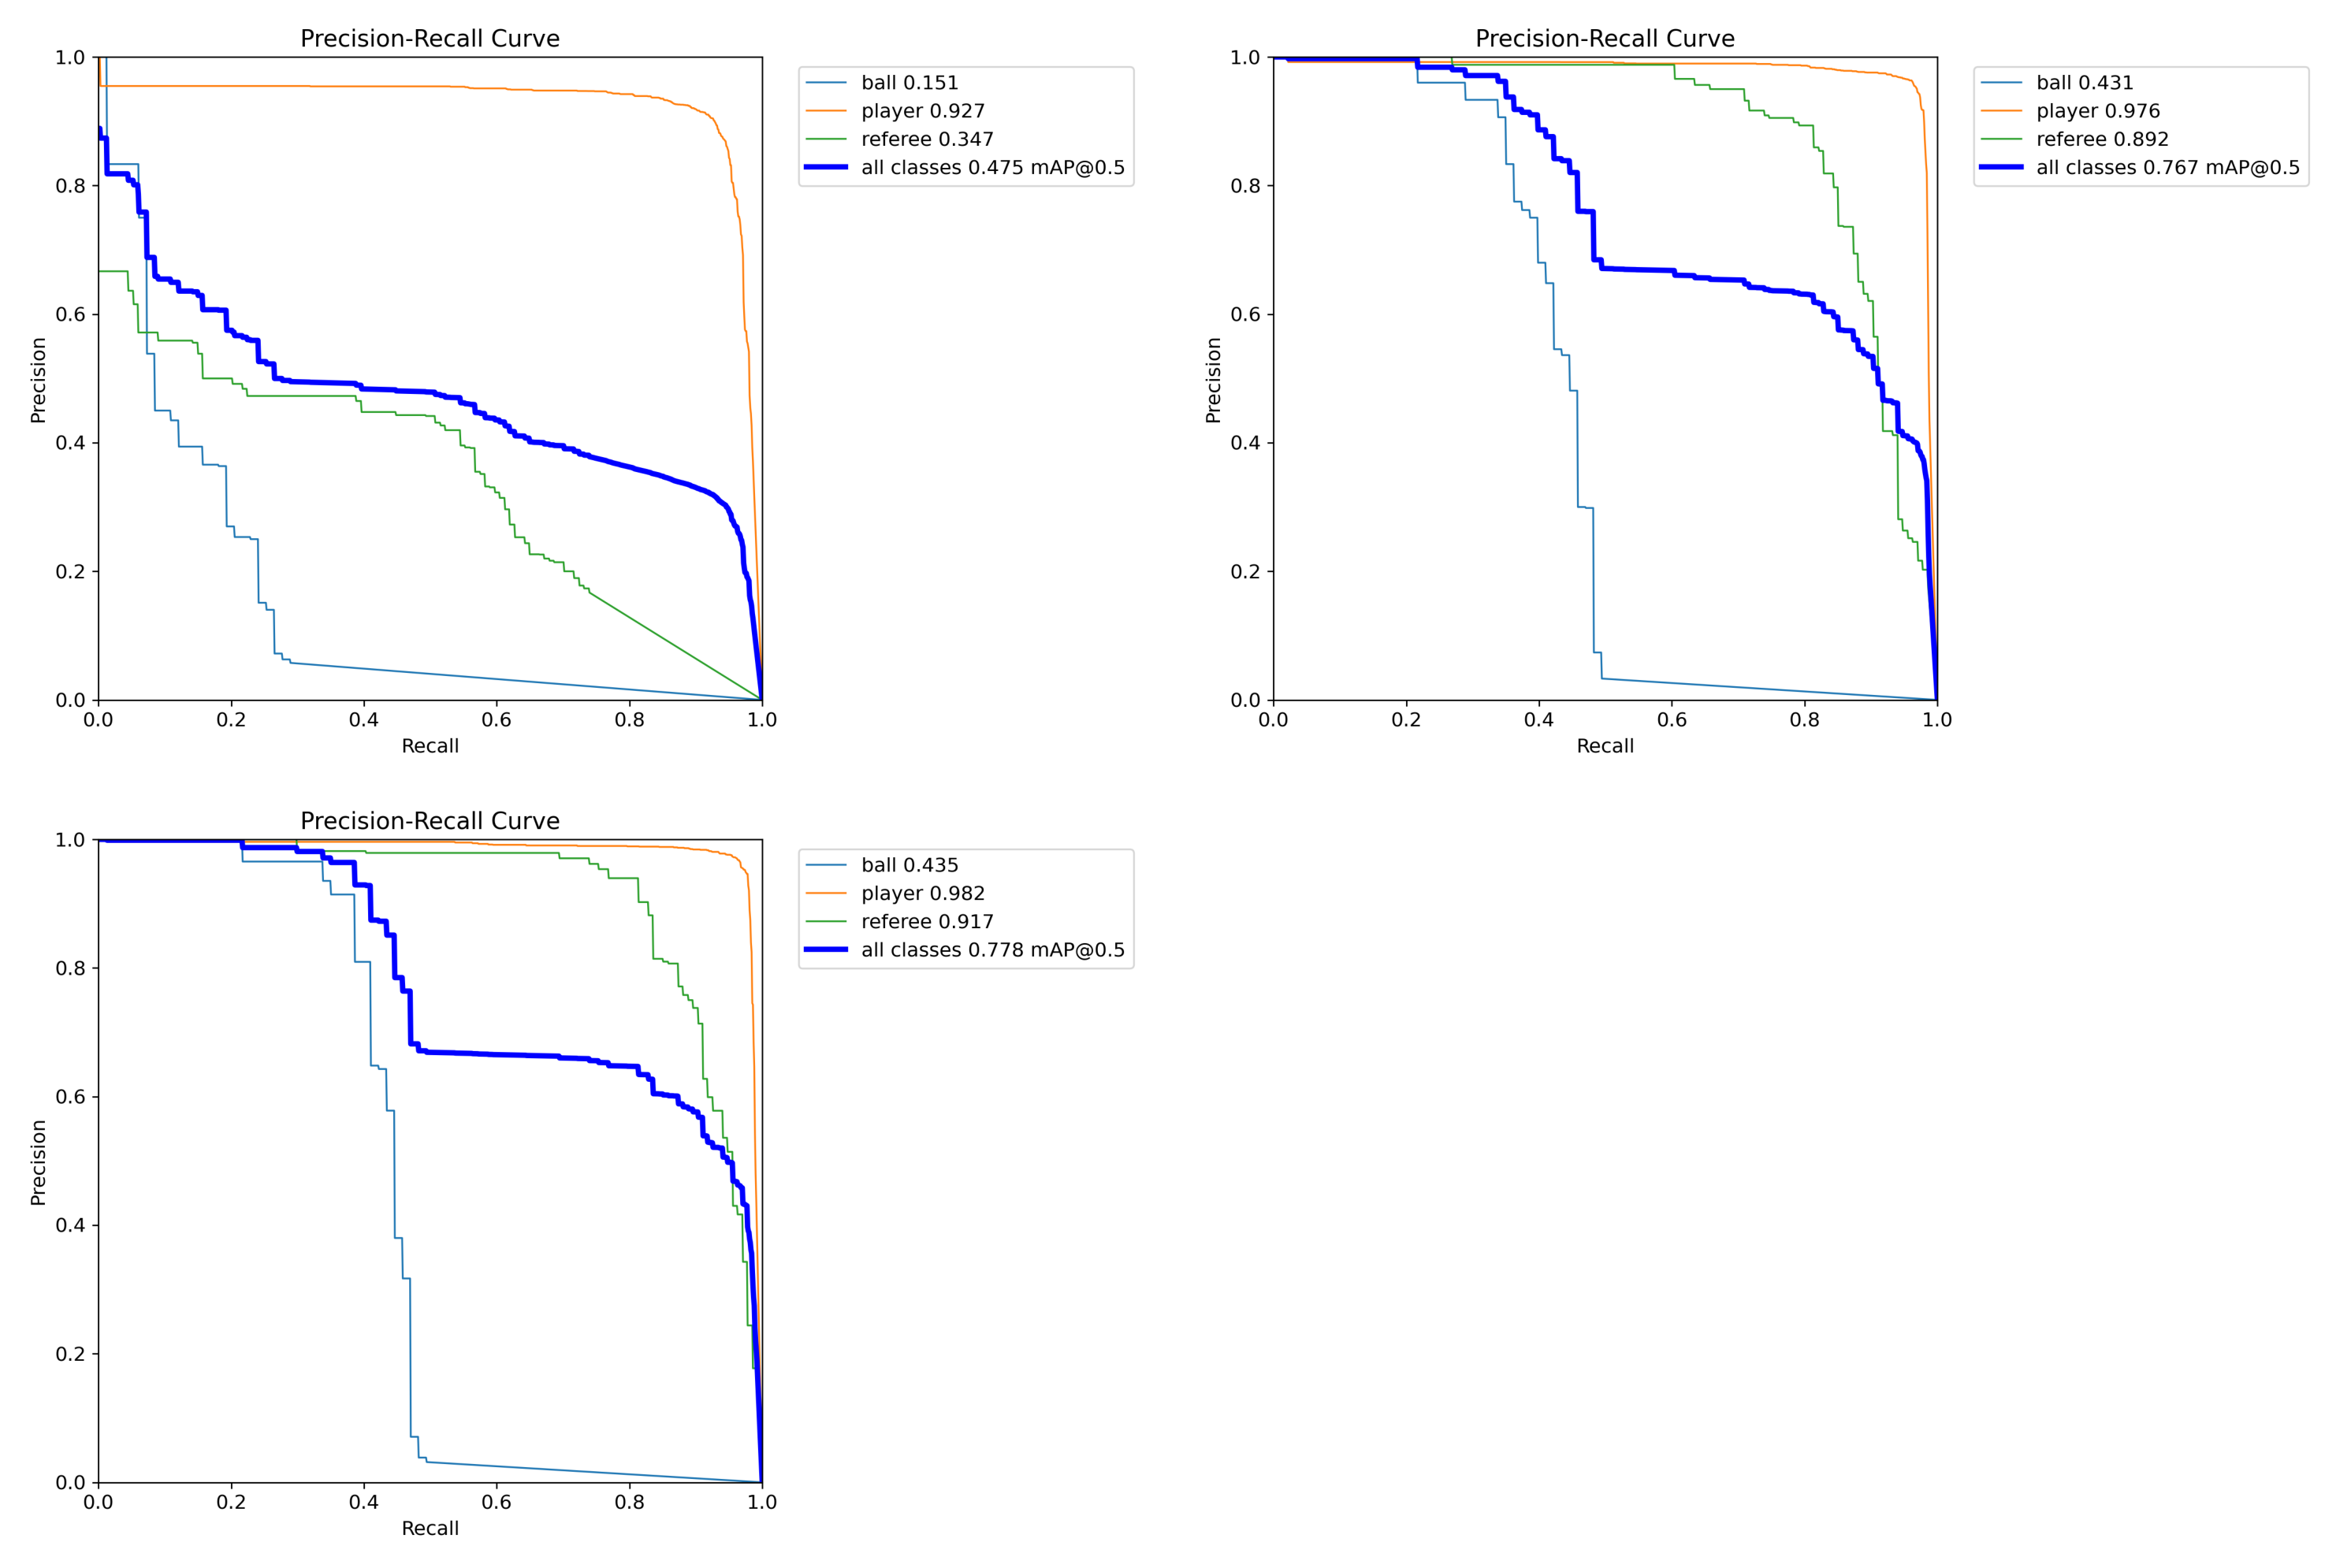

In [26]:
boxpr_it_0 = os.path.join(OBJ_DETECTION_RUN0,"custom_test","BoxPR_curve.png")
boxpr_it_1 = os.path.join(OBJ_DETECTION_RUN1,"custom_test","BoxPR_curve.png")
boxpr_it_2 = os.path.join(OBJ_DETECTION_RUN2,"custom_test","BoxPR_curve.png")

display_image([boxpr_it_0,boxpr_it_1,boxpr_it_2])

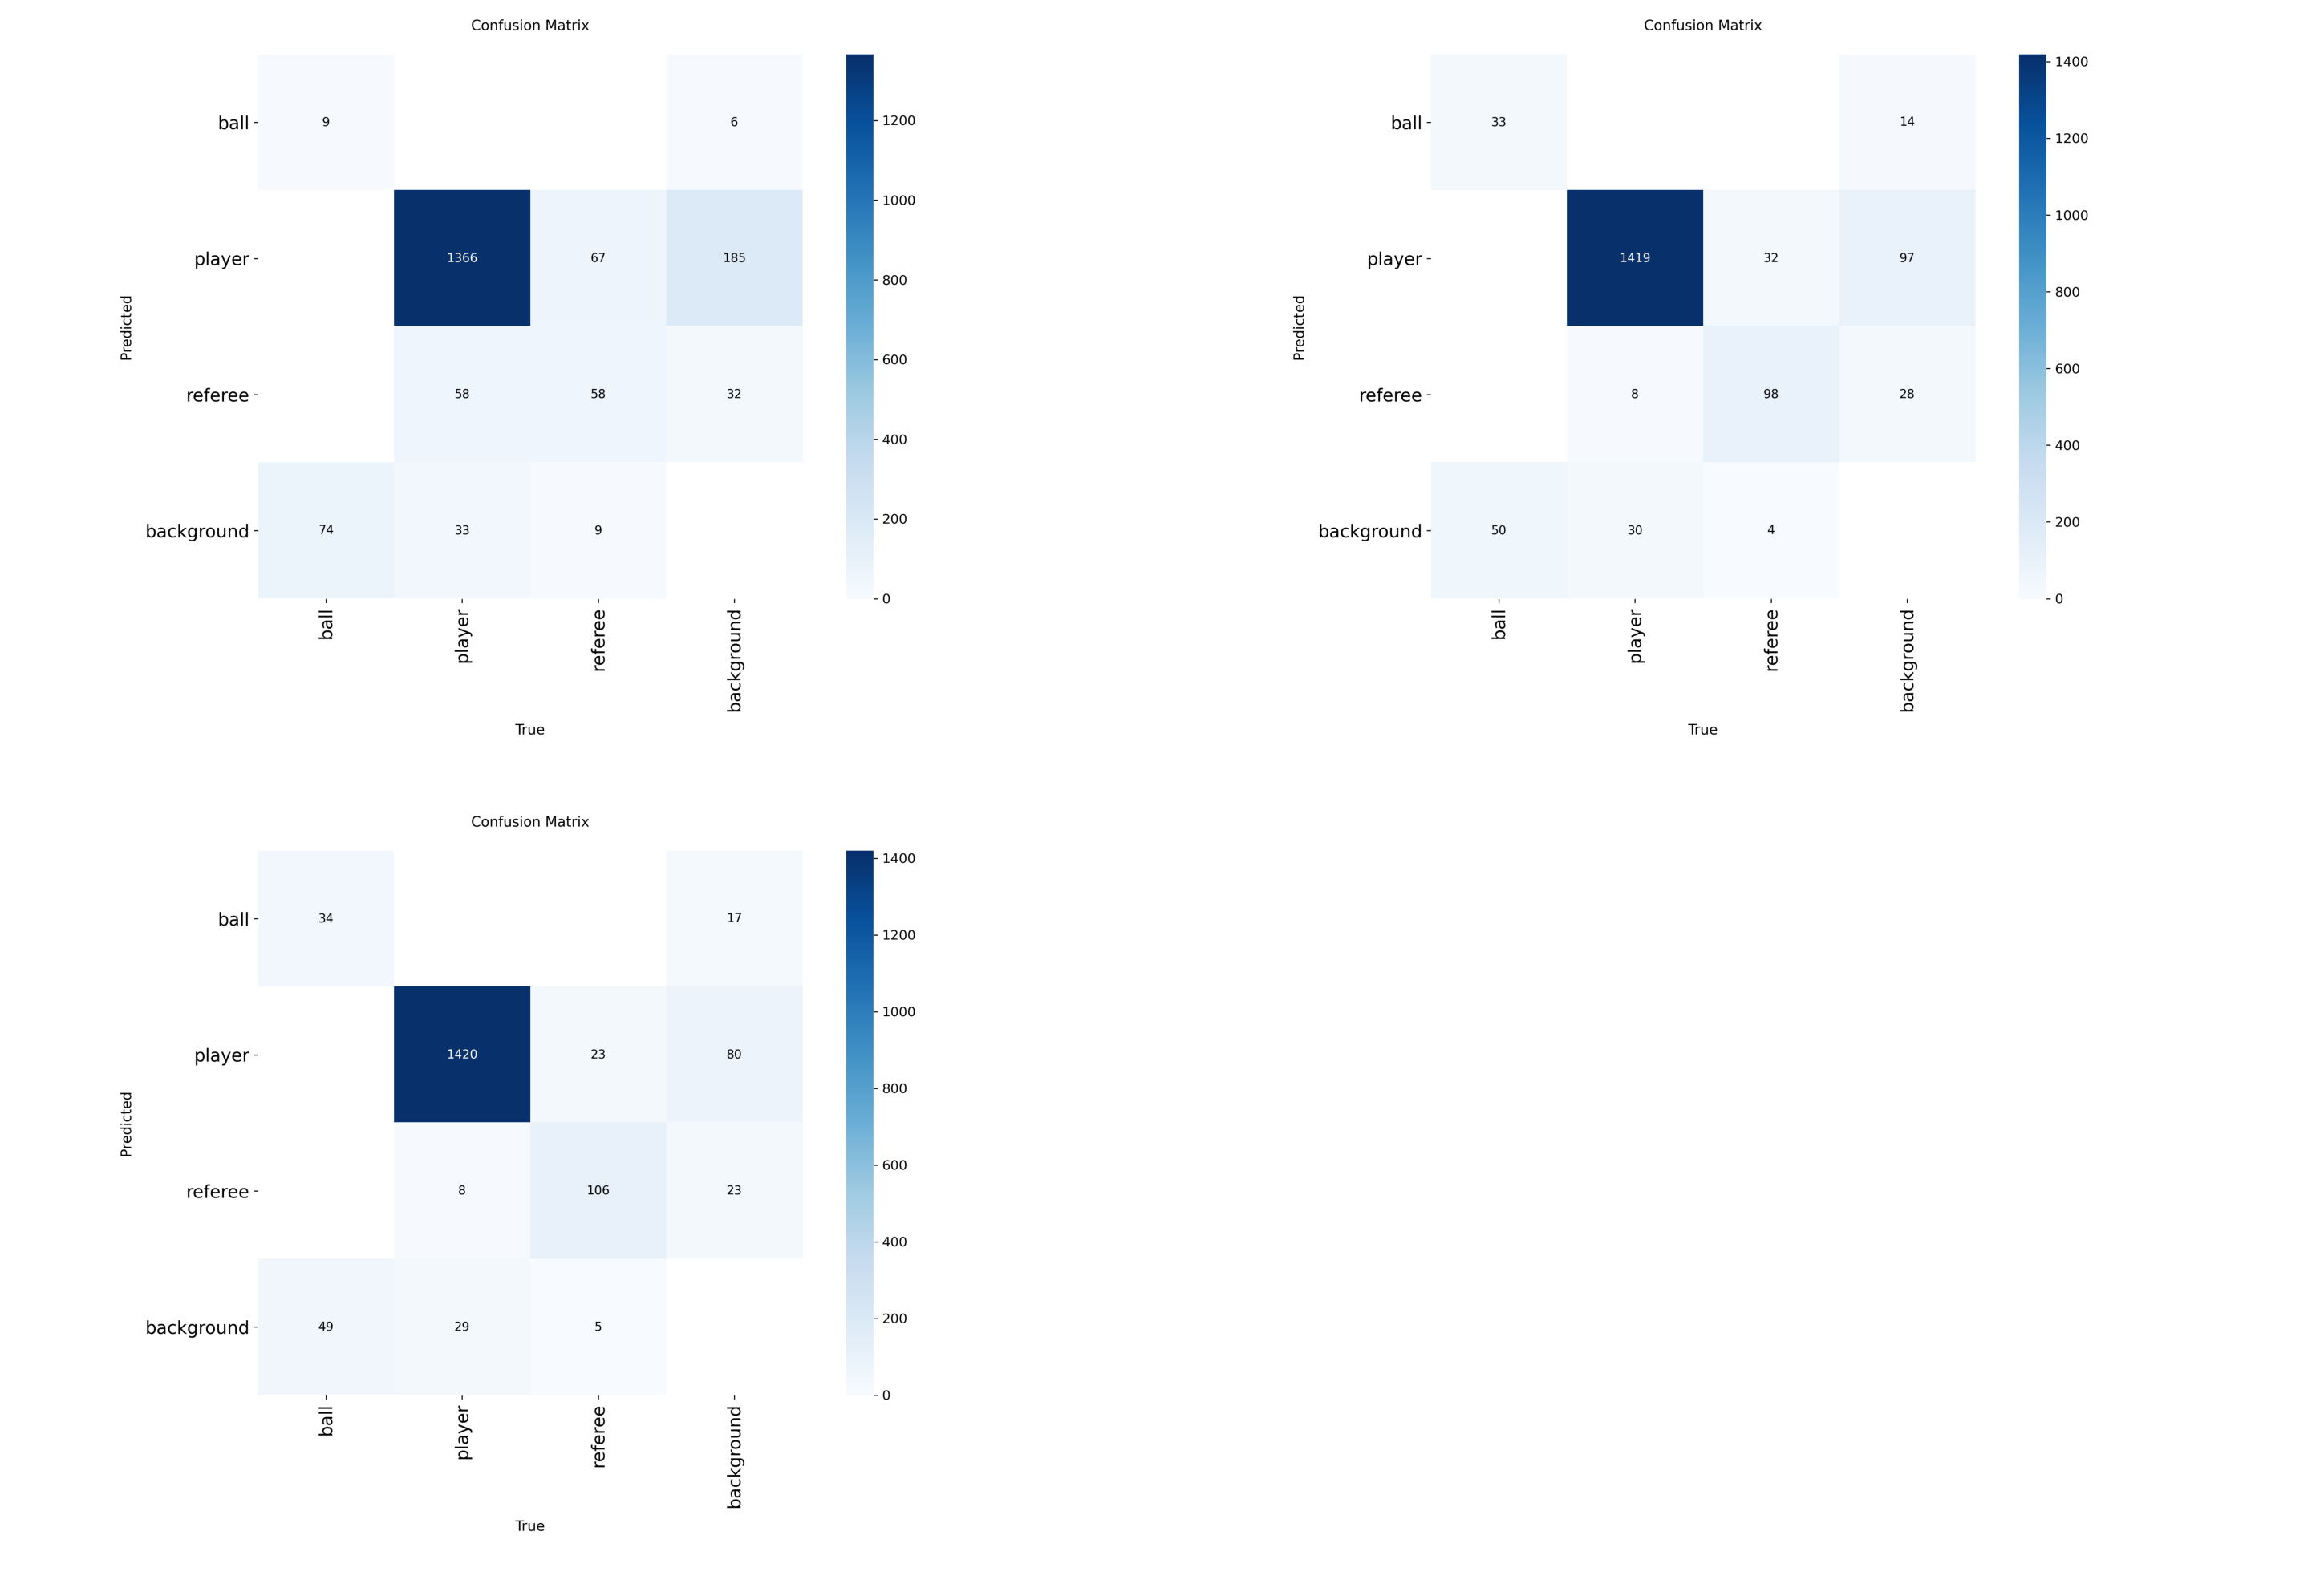

In [27]:
confusion_matrix_it_0 = os.path.join(OBJ_DETECTION_RUN0,"custom_test","confusion_matrix.png")
confusion_matrix_it_1 = os.path.join(OBJ_DETECTION_RUN1,"custom_test","confusion_matrix.png")
confusion_matrix_it_2 = os.path.join(OBJ_DETECTION_RUN2,"custom_test","confusion_matrix.png")

display_image([confusion_matrix_it_0,confusion_matrix_it_1,confusion_matrix_it_2])

En conjunto, los resultados obtenidos muestran que el modelo presenta un buen rendimiento general, especialmente en la identificación de jugadores y árbitros, clases para las que se alcanzan valores elevados de precisión y recall de forma consistente. 

Sin embargo, el principal punto débil del sistema es la detección del balón, tal y como se observa en las gráficas de precisión–recall y en las matrices de confusión, donde esta clase concentra la mayoría de los errores.

Esta limitación se explica principalmente por el reducido tamaño del balón en comparación con el resto de objetos, así como por su frecuente solapamiento con otros elementos, como jugadores u otras partes de la escena, lo que dificulta su correcta localización. 

Además, se trata de una clase fuertemente desbalanceada respecto a jugadores y árbitros, lo que penaliza el aprendizaje del modelo y afecta negativamente a su capacidad de detección. 

En consecuencia, aunque el modelo demuestra ser robusto en la detección de entidades principales del juego, la mejora del rendimiento en la clase balón constituye la principal línea de trabajo futuro

# Videos
A modo de prueba decidimos mostrar un par de videos para ver el desempeño real del modelo:

In [11]:
from ia_futbol.utils.config import BEST_OBJ_DETECTION_MODEL
from ia_futbol.utils.config import VIDEOS_DIR
import ia_futbol.utils.image_tools as it
import ia_futbol.utils.video_tools as vt

model = YOLO(BEST_OBJ_DETECTION_MODEL)
OBJ_DETECTION_VIDEOS = os.path.join(VIDEOS_DIR,"object_detection")

In [12]:
def write_frame(frame, **kwargs):
    results = model(frame,verbose = False)[0]
    detections = sv.Detections.from_ultralytics(results)

    ball = detections[detections.class_id == 0]
    players = detections[detections.class_id == 1]
    referees = detections[detections.class_id == 2]

    annotated_frame = it.draw_annotations(frame,ball,color="#0066FF") #Balon en azul
    annotated_frame = it.draw_annotations(annotated_frame,players,color="#00FF00") #Jugadores en verde
    annotated_frame = it.draw_annotations(annotated_frame,referees,color="#FF0000") #Arbitros en rojo

    return annotated_frame


videos = os.listdir(os.path.join(VIDEOS_DIR,"downloaded"))

for video in videos:
    video_path = os.path.join(VIDEOS_DIR,"downloaded",video)
    output_video_path = os.path.join(OBJ_DETECTION_VIDEOS,video)
    vt.process_and_write_video(video_path,
                               output_path=output_video_path,
                               process_frame_func=write_frame)



Procesando video:  97%|█████████▋| 3001/3085 [01:54<00:03, 26.25it/s]


In [13]:
def write_frame(frame, **kwargs):
    results = model(frame,verbose = False)[0]
    detections = sv.Detections.from_ultralytics(results)

    ball = detections[detections.class_id == 0]
    players = detections[detections.class_id == 1]
    referees = detections[detections.class_id == 2]

    annotated_frame = it.annotate_ball(frame,ball) 
    annotated_frame = it.draw_annotations(annotated_frame,players,color="#00FF00",stylized=True) #Jugadores en verde
    annotated_frame = it.draw_annotations(annotated_frame,referees,color="#FF0000",stylized=True) #Arbitros en rojo

    return annotated_frame


videos = os.listdir(os.path.join(VIDEOS_DIR,"downloaded"))

i = 0
for video in videos:
    video_path = os.path.join(VIDEOS_DIR,"downloaded",video)
    output_video_path = os.path.join(OBJ_DETECTION_VIDEOS,f'stylized_{video}.mp4')
    vt.process_and_write_video(video_path,
                               output_path=output_video_path,
                               process_frame_func=write_frame)

Procesando video:  97%|█████████▋| 3001/3085 [01:55<00:03, 25.91it/s]
